# Jawaban Coding Test - Sharing Vision

**Dataset:** employee.csv (1470 rows x 35 features)

**Target Classification:** Attrition | **Target Regression:** MonthlyIncome

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, r2_score,
    mean_squared_error, mean_absolute_error, mean_absolute_percentage_error)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

df_raw = pd.read_csv('employee.csv')
print(f"Dataset shape: {df_raw.shape}")
df_raw.head()


Dataset shape: (2940, 35)


,Unnamed: 0,EmployeeNumber,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0,1,Yes,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,...,1,80,0,8,0,1,6,4,0,5
1,1,2,No,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,...,4,80,1,10,3,3,10,7,1,7
2,2,3,Yes,37,Travel_Rarely,1373,Research & Development,2,2,Other,...,2,80,0,7,3,3,0,0,0,0
3,3,4,No,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,...,3,80,0,8,3,3,8,7,3,0
4,4,5,No,27,Travel_Rarely,591,Research & Development,2,1,Medical,...,4,80,1,6,3,3,2,2,2,2


## EDA

Exploratory Data Analysis pada dataset employee.csv

### Task (1): Drop Kolom Tidak Diperlukan & Univariate EDA - Numerical Columns

Drop kolom yang tidak relevan, kemudian lakukan EDA univariat pada setiap kolom numerik:
histogram, boxplot, statistik dasar, whisker, outlier, dan insight.

Shape setelah drop: (2940, 31)
Kolom numerik (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']



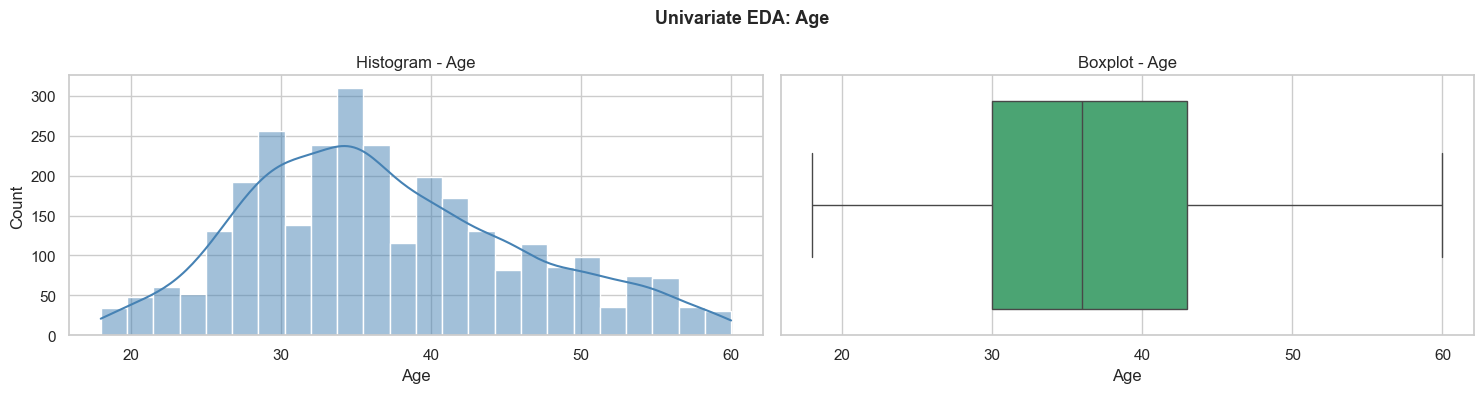

[Age]
  Mean=36.92 | Std=9.13 | Min=18.0 | Q1=30.0 | Q2=36.0 | Q3=43.0 | IQR=13.00 | Max=60.0
  Lower Whisker=18 | Upper Whisker=60
  Tidak ditemukan outlier berdasarkan aturan 1.5xIQR.



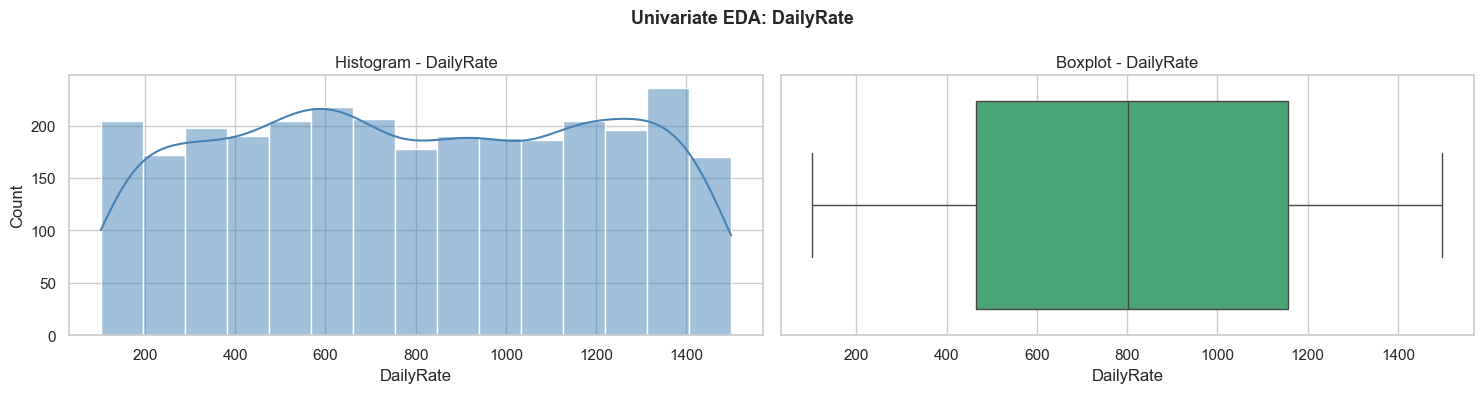

[DailyRate]
  Mean=802.49 | Std=403.44 | Min=102.0 | Q1=465.0 | Q2=802.0 | Q3=1157.0 | IQR=692.00 | Max=1499.0
  Lower Whisker=102 | Upper Whisker=1499
  Tidak ditemukan outlier berdasarkan aturan 1.5xIQR.



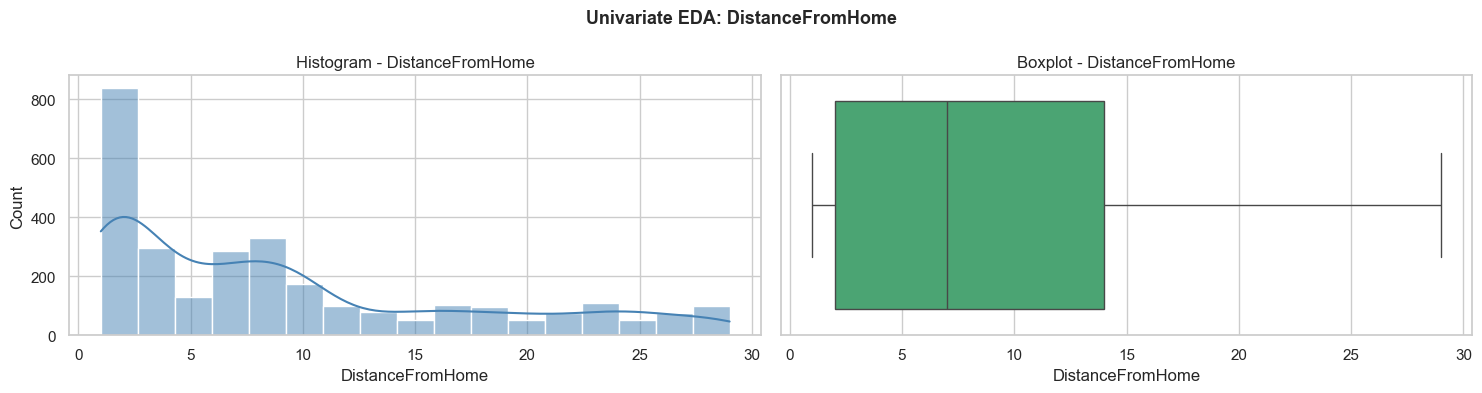

[DistanceFromHome]
  Mean=9.19 | Std=8.11 | Min=1.0 | Q1=2.0 | Q2=7.0 | Q3=14.0 | IQR=12.00 | Max=29.0
  Lower Whisker=1 | Upper Whisker=29
  Tidak ditemukan outlier berdasarkan aturan 1.5xIQR.



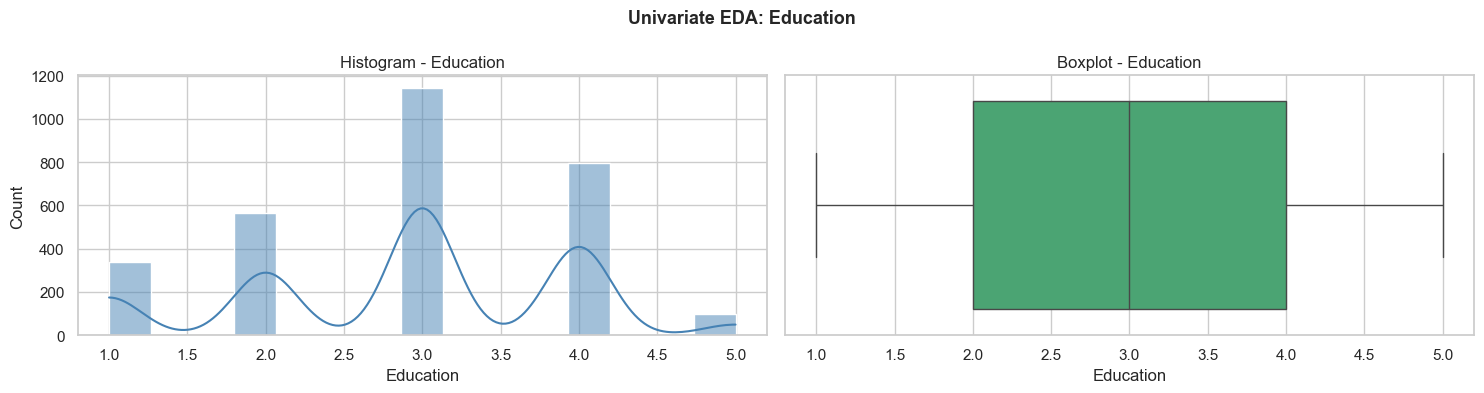

[Education]
  Mean=2.91 | Std=1.02 | Min=1.0 | Q1=2.0 | Q2=3.0 | Q3=4.0 | IQR=2.00 | Max=5.0
  Lower Whisker=1 | Upper Whisker=5
  Tidak ditemukan outlier berdasarkan aturan 1.5xIQR.



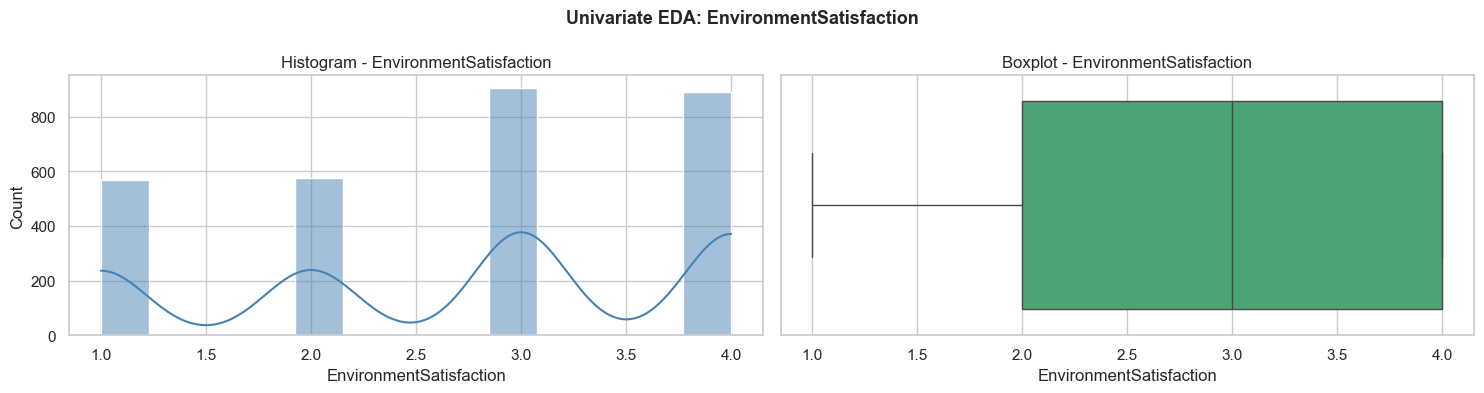

[EnvironmentSatisfaction]
  Mean=2.72 | Std=1.09 | Min=1.0 | Q1=2.0 | Q2=3.0 | Q3=4.0 | IQR=2.00 | Max=4.0
  Lower Whisker=1 | Upper Whisker=4
  Tidak ditemukan outlier berdasarkan aturan 1.5xIQR.



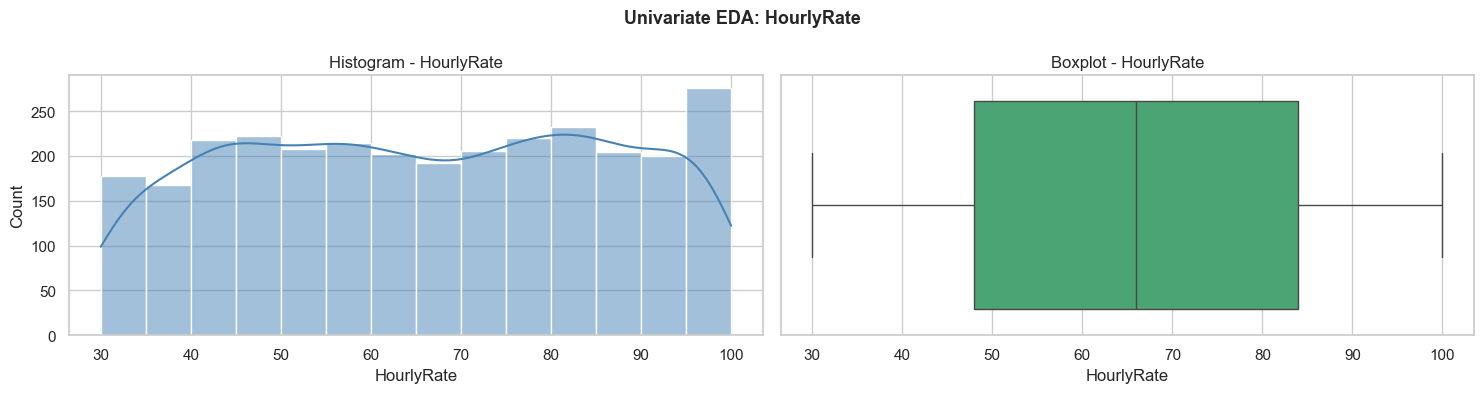

[HourlyRate]
  Mean=65.89 | Std=20.33 | Min=30.0 | Q1=48.0 | Q2=66.0 | Q3=84.0 | IQR=36.00 | Max=100.0
  Lower Whisker=30 | Upper Whisker=100
  Tidak ditemukan outlier berdasarkan aturan 1.5xIQR.



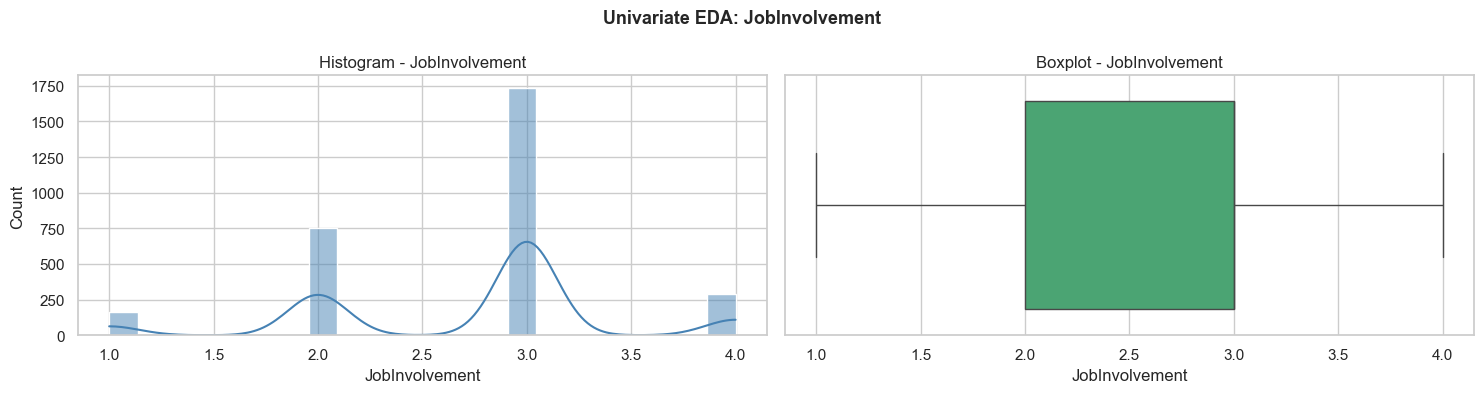

[JobInvolvement]
  Mean=2.73 | Std=0.71 | Min=1.0 | Q1=2.0 | Q2=3.0 | Q3=3.0 | IQR=1.00 | Max=4.0
  Lower Whisker=1 | Upper Whisker=4
  Tidak ditemukan outlier berdasarkan aturan 1.5xIQR.



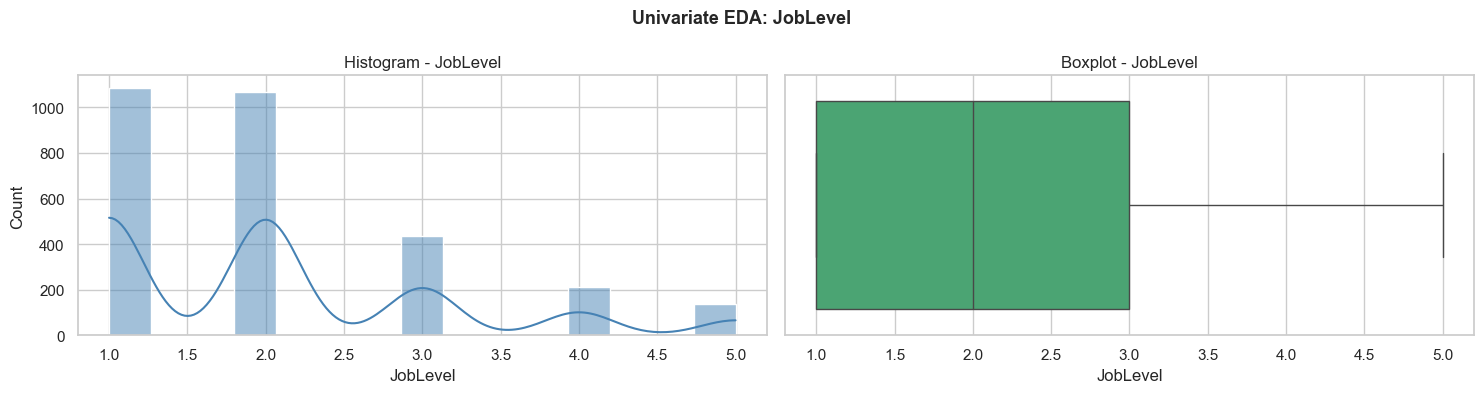

[JobLevel]
  Mean=2.06 | Std=1.11 | Min=1.0 | Q1=1.0 | Q2=2.0 | Q3=3.0 | IQR=2.00 | Max=5.0
  Lower Whisker=1 | Upper Whisker=5
  Tidak ditemukan outlier berdasarkan aturan 1.5xIQR.



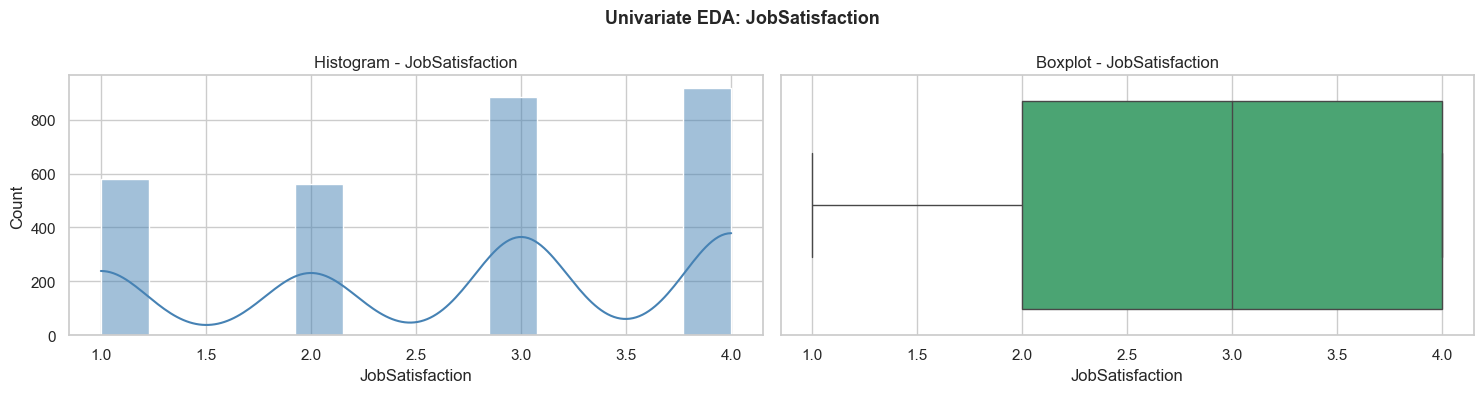

[JobSatisfaction]
  Mean=2.73 | Std=1.10 | Min=1.0 | Q1=2.0 | Q2=3.0 | Q3=4.0 | IQR=2.00 | Max=4.0
  Lower Whisker=1 | Upper Whisker=4
  Tidak ditemukan outlier berdasarkan aturan 1.5xIQR.



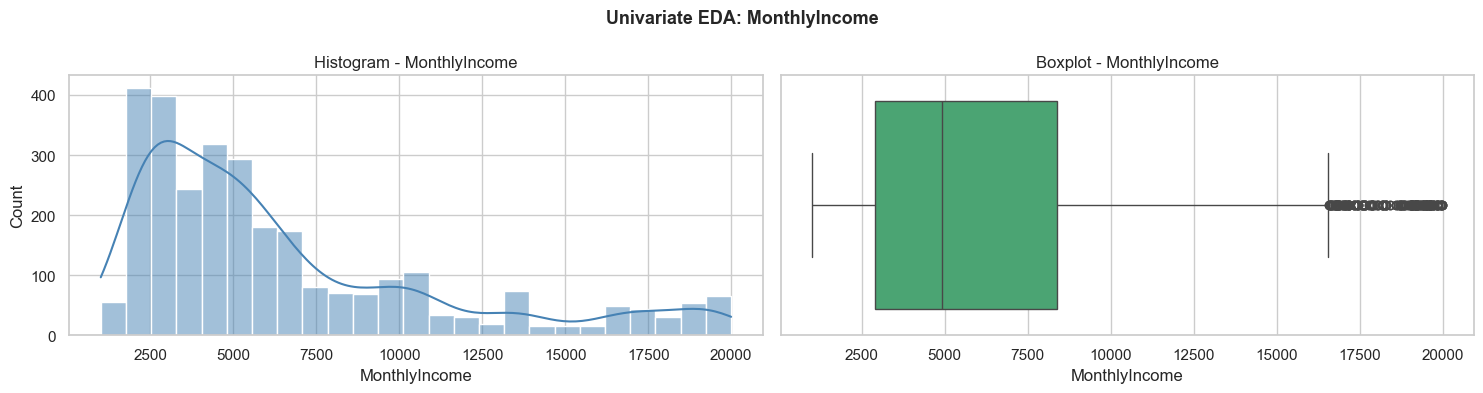

[MonthlyIncome]
  Mean=6502.93 | Std=4707.16 | Min=1009.0 | Q1=2911.0 | Q2=4919.0 | Q3=8380.0 | IQR=5469.00 | Max=19999.0
  Lower Whisker=1009 | Upper Whisker=16555
  Outlier: 228 data (7.76%)
  Contoh nilai outlier: [16595, 16598, 16606, 16627, 16659, 16704, 16752, 16756, 16792, 16799]



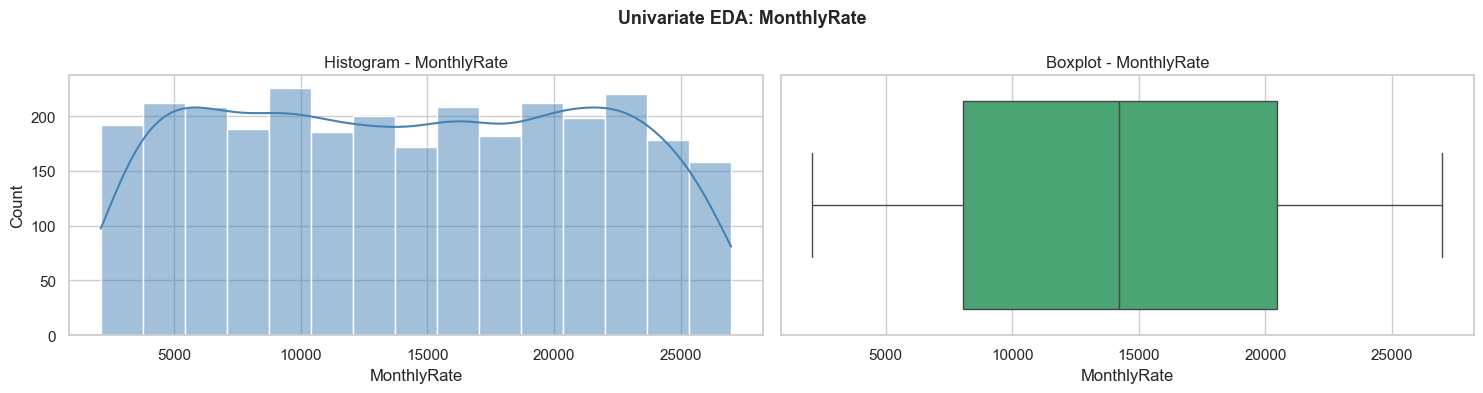

[MonthlyRate]
  Mean=14313.10 | Std=7116.58 | Min=2094.0 | Q1=8045.0 | Q2=14235.5 | Q3=20462.0 | IQR=12417.00 | Max=26999.0
  Lower Whisker=2094 | Upper Whisker=26999
  Tidak ditemukan outlier berdasarkan aturan 1.5xIQR.



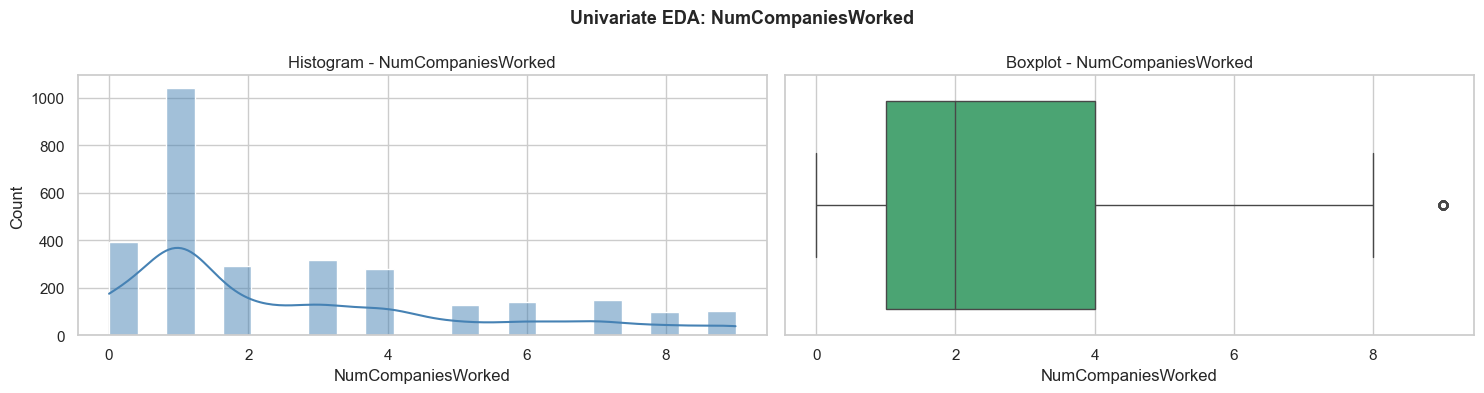

[NumCompaniesWorked]
  Mean=2.69 | Std=2.50 | Min=0.0 | Q1=1.0 | Q2=2.0 | Q3=4.0 | IQR=3.00 | Max=9.0
  Lower Whisker=0 | Upper Whisker=8
  Outlier: 104 data (3.54%)
  Contoh nilai outlier: [9]



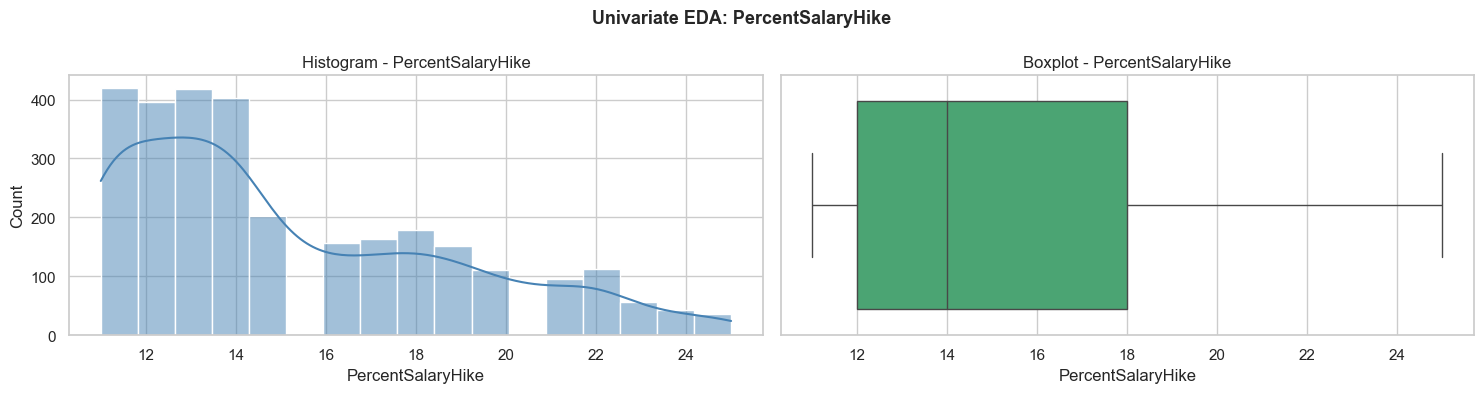

[PercentSalaryHike]
  Mean=15.21 | Std=3.66 | Min=11.0 | Q1=12.0 | Q2=14.0 | Q3=18.0 | IQR=6.00 | Max=25.0
  Lower Whisker=11 | Upper Whisker=25
  Tidak ditemukan outlier berdasarkan aturan 1.5xIQR.



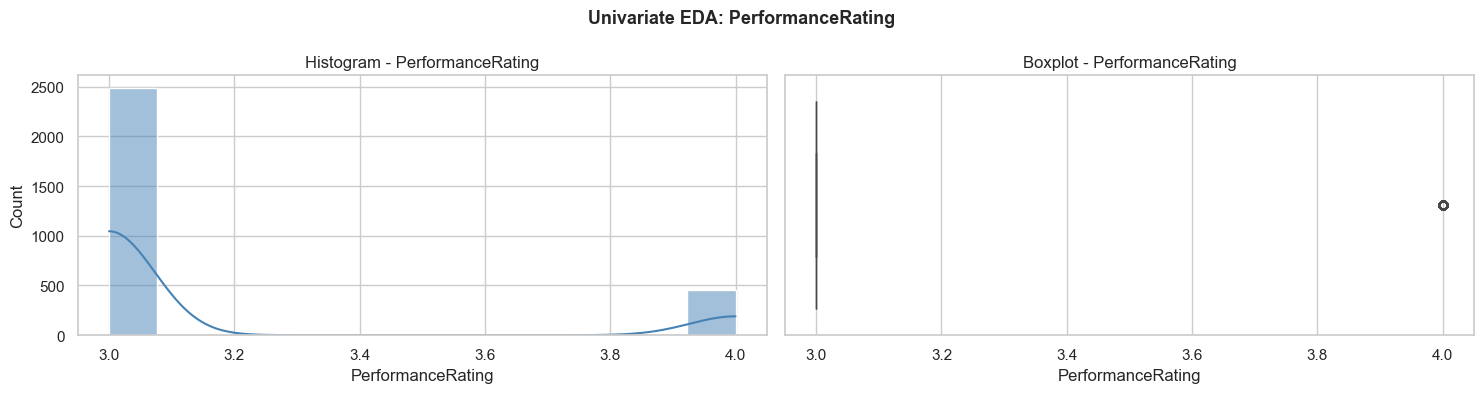

[PerformanceRating]
  Mean=3.15 | Std=0.36 | Min=3.0 | Q1=3.0 | Q2=3.0 | Q3=3.0 | IQR=0.00 | Max=4.0
  Lower Whisker=3 | Upper Whisker=3
  Outlier: 452 data (15.37%)
  Contoh nilai outlier: [4]



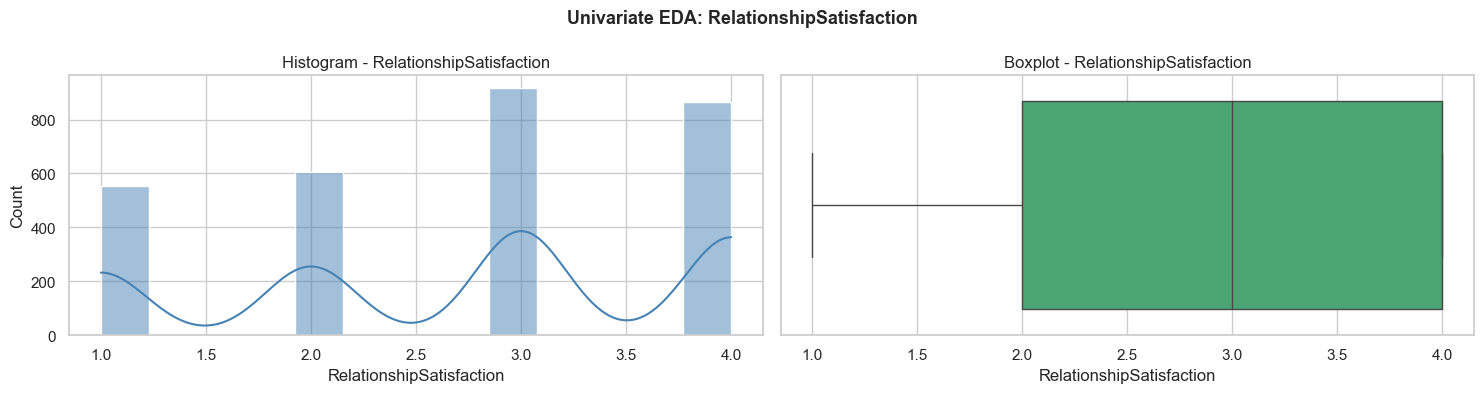

[RelationshipSatisfaction]
  Mean=2.71 | Std=1.08 | Min=1.0 | Q1=2.0 | Q2=3.0 | Q3=4.0 | IQR=2.00 | Max=4.0
  Lower Whisker=1 | Upper Whisker=4
  Tidak ditemukan outlier berdasarkan aturan 1.5xIQR.



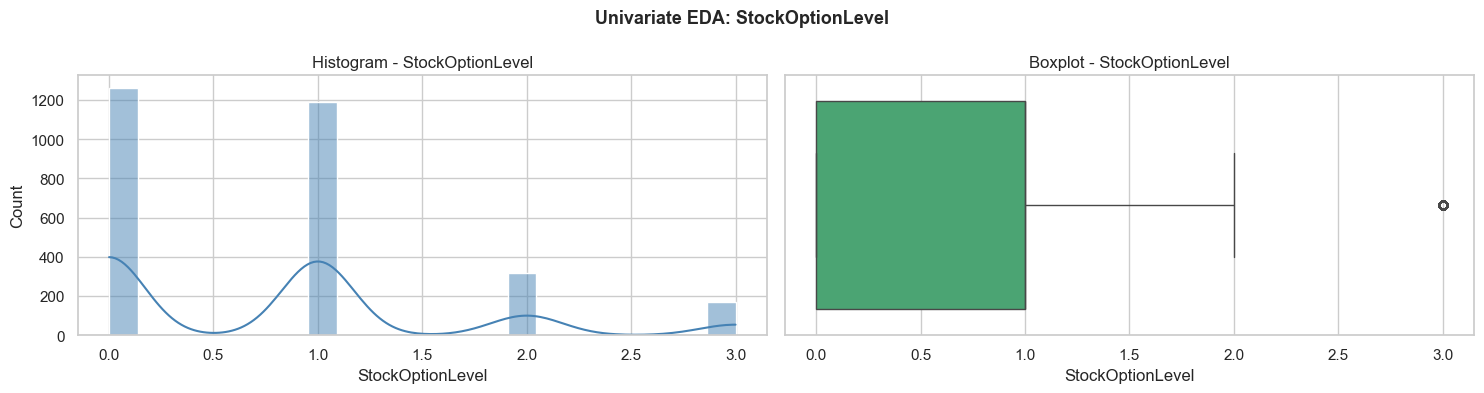

[StockOptionLevel]
  Mean=0.79 | Std=0.85 | Min=0.0 | Q1=0.0 | Q2=1.0 | Q3=1.0 | IQR=1.00 | Max=3.0
  Lower Whisker=0 | Upper Whisker=2
  Outlier: 170 data (5.78%)
  Contoh nilai outlier: [3]



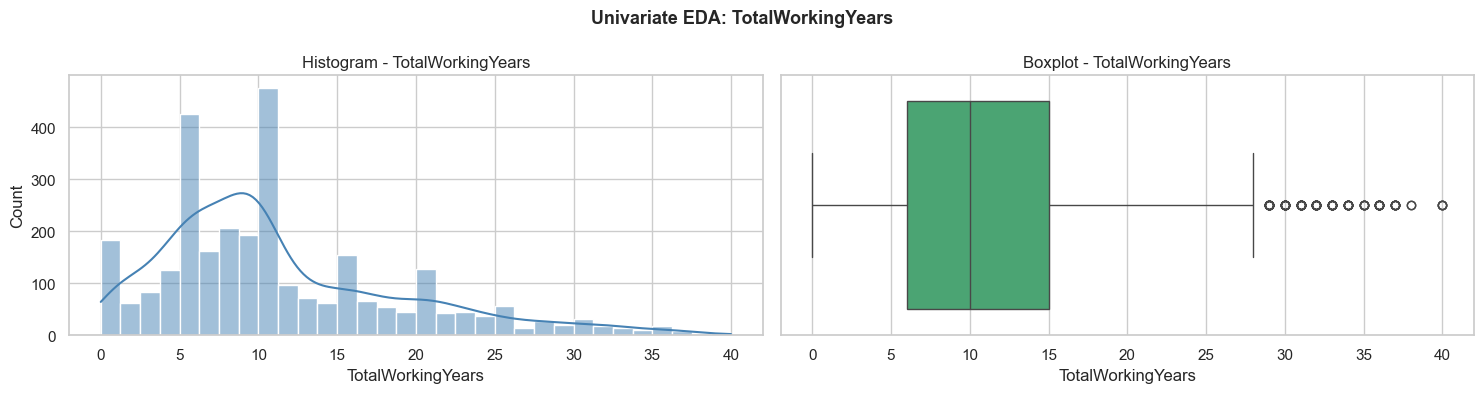

[TotalWorkingYears]
  Mean=11.28 | Std=7.78 | Min=0.0 | Q1=6.0 | Q2=10.0 | Q3=15.0 | IQR=9.00 | Max=40.0
  Lower Whisker=0 | Upper Whisker=28
  Outlier: 126 data (4.29%)
  Contoh nilai outlier: [29, 30, 31, 32, 33, 34, 35, 36, 37, 38]



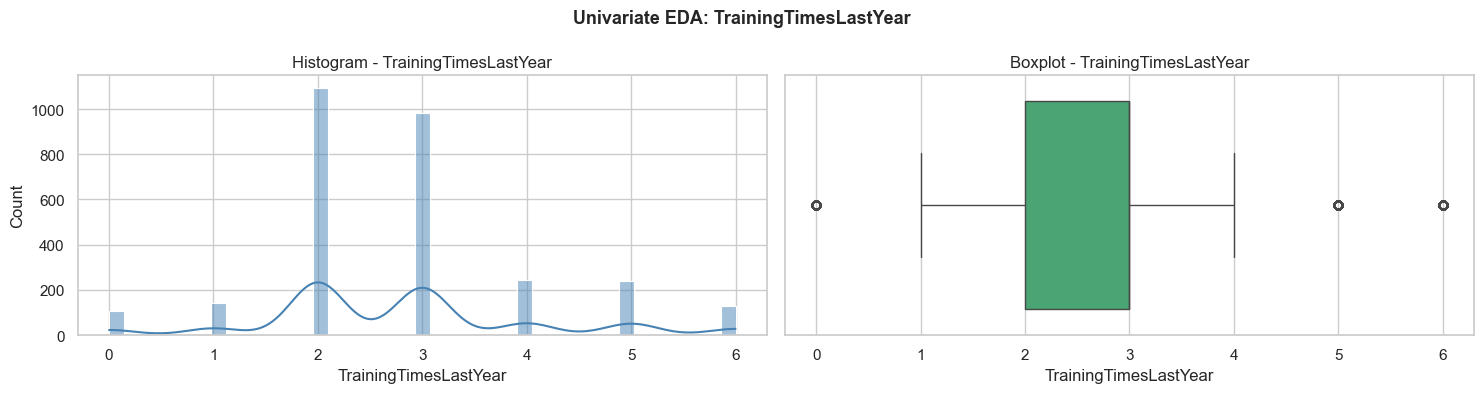

[TrainingTimesLastYear]
  Mean=2.80 | Std=1.29 | Min=0.0 | Q1=2.0 | Q2=3.0 | Q3=3.0 | IQR=1.00 | Max=6.0
  Lower Whisker=1 | Upper Whisker=4
  Outlier: 476 data (16.19%)
  Contoh nilai outlier: [0, 5, 6]



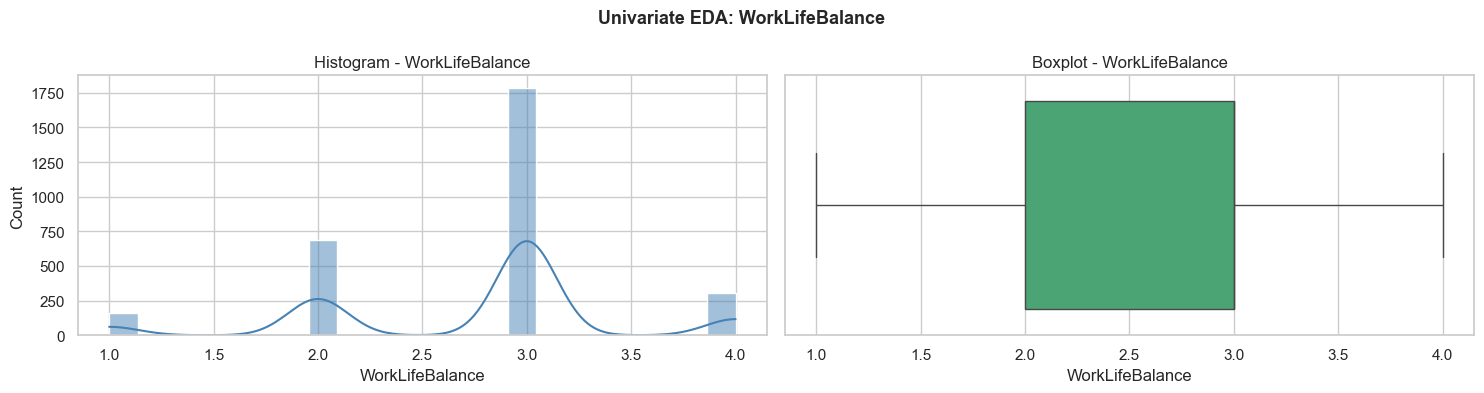

[WorkLifeBalance]
  Mean=2.76 | Std=0.71 | Min=1.0 | Q1=2.0 | Q2=3.0 | Q3=3.0 | IQR=1.00 | Max=4.0
  Lower Whisker=1 | Upper Whisker=4
  Tidak ditemukan outlier berdasarkan aturan 1.5xIQR.



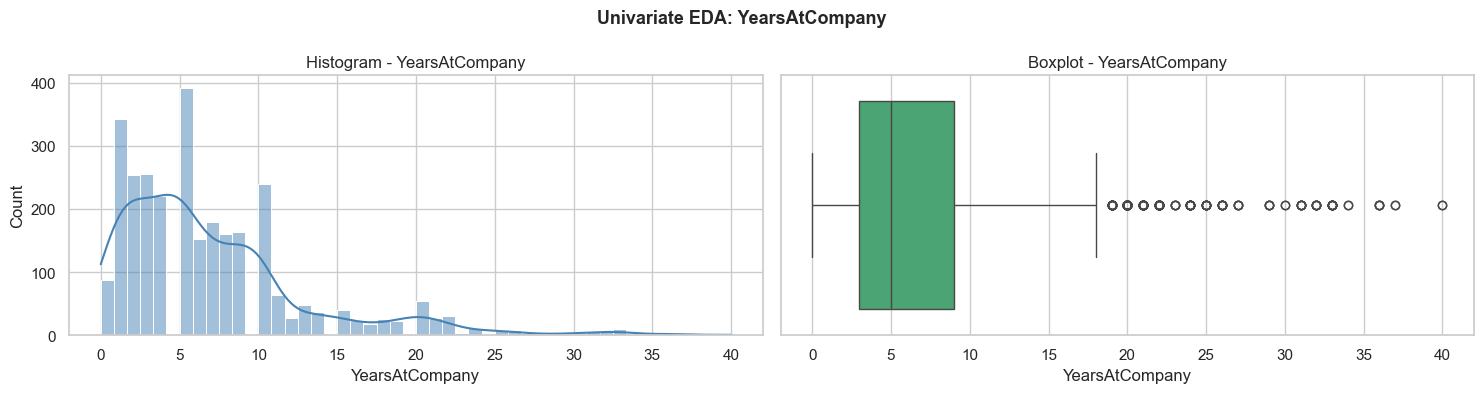

[YearsAtCompany]
  Mean=7.01 | Std=6.13 | Min=0.0 | Q1=3.0 | Q2=5.0 | Q3=9.0 | IQR=6.00 | Max=40.0
  Lower Whisker=0 | Upper Whisker=18
  Outlier: 208 data (7.07%)
  Contoh nilai outlier: [19, 20, 21, 22, 23, 24, 25, 26, 27, 29]



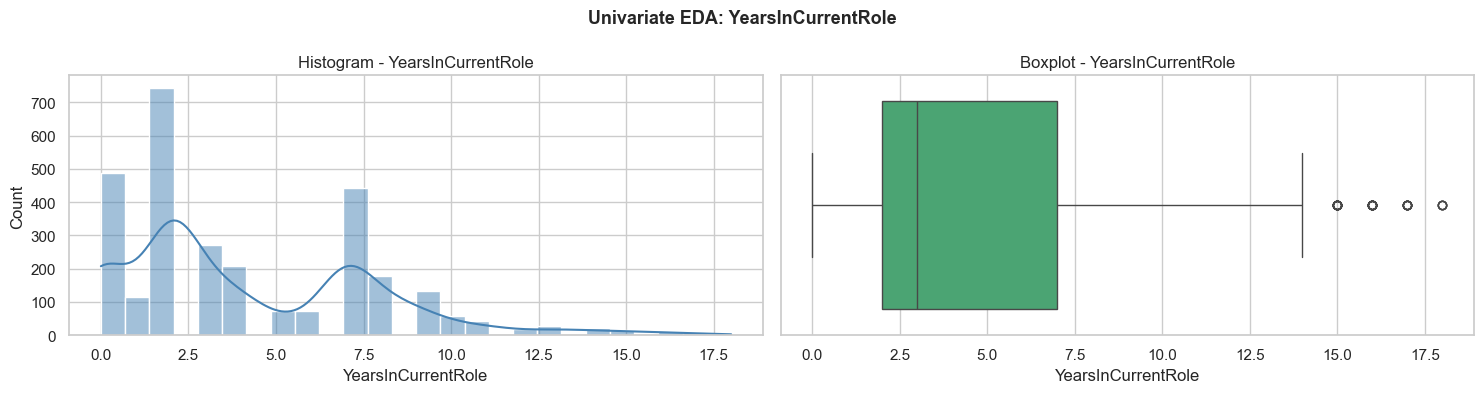

[YearsInCurrentRole]
  Mean=4.23 | Std=3.62 | Min=0.0 | Q1=2.0 | Q2=3.0 | Q3=7.0 | IQR=5.00 | Max=18.0
  Lower Whisker=0 | Upper Whisker=14
  Outlier: 42 data (1.43%)
  Contoh nilai outlier: [15, 16, 17, 18]



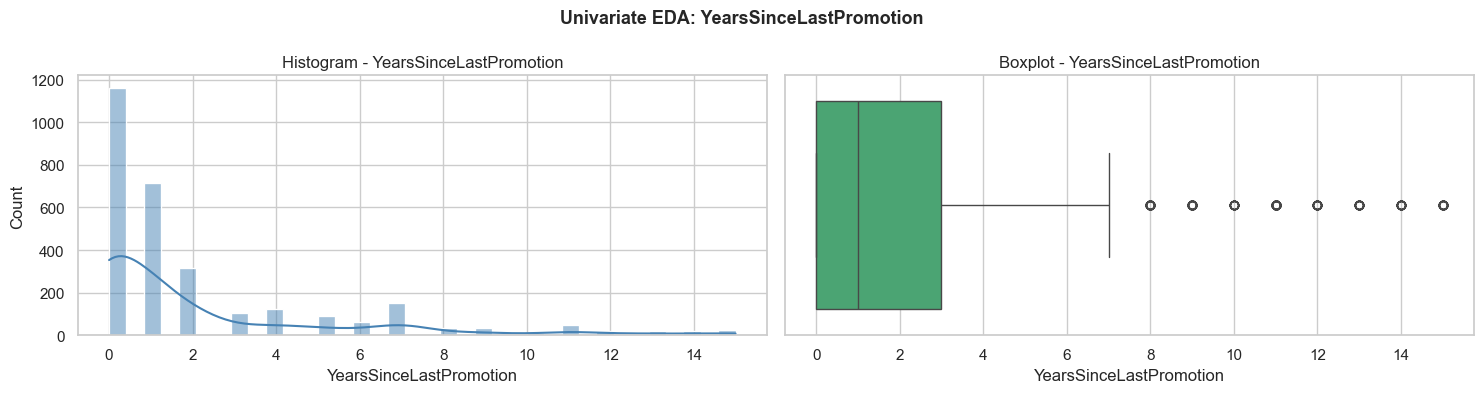

[YearsSinceLastPromotion]
  Mean=2.19 | Std=3.22 | Min=0.0 | Q1=0.0 | Q2=1.0 | Q3=3.0 | IQR=3.00 | Max=15.0
  Lower Whisker=0 | Upper Whisker=7
  Outlier: 214 data (7.28%)
  Contoh nilai outlier: [8, 9, 10, 11, 12, 13, 14, 15]



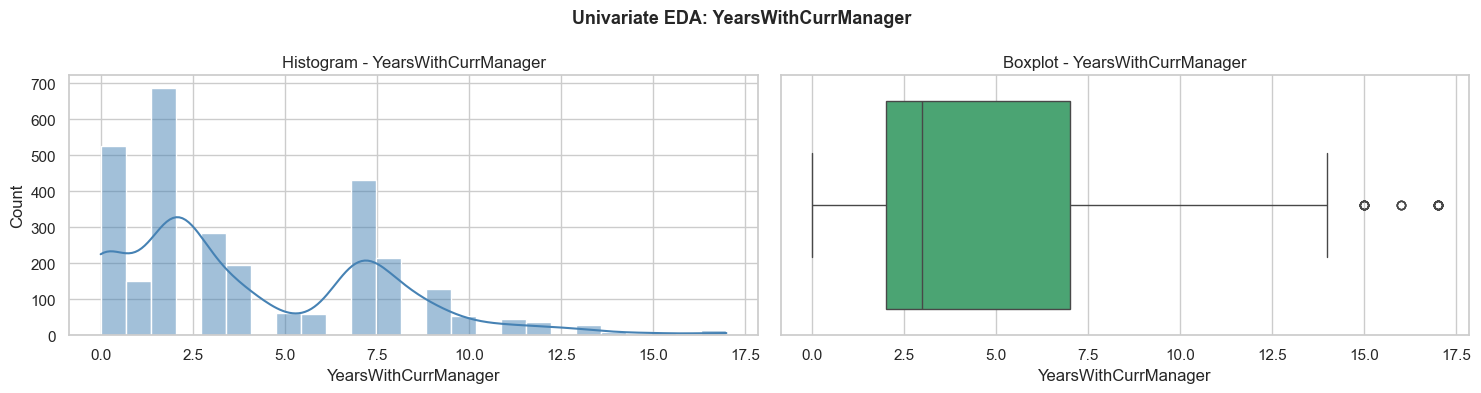

[YearsWithCurrManager]
  Mean=4.12 | Std=3.57 | Min=0.0 | Q1=2.0 | Q2=3.0 | Q3=7.0 | IQR=5.00 | Max=17.0
  Lower Whisker=0 | Upper Whisker=14
  Outlier: 28 data (0.95%)
  Contoh nilai outlier: [15, 16, 17]


==== INSIGHT TASK 1 ====
- MonthlyIncome: distribusi sangat right-skewed, terdapat outlier signifikan di atas
  (mencerminkan struktur gaji eksekutif yang jauh lebih tinggi dari rata-rata)
- Age: distribusi mendekati normal, rentang 18-60 tahun, tidak ada outlier ekstrem
- Variabel tenure (YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager,
  TotalWorkingYears): right-skewed, menunjukkan mayoritas karyawan masih relatif baru
- DailyRate, HourlyRate, MonthlyRate: distribusi relatif seragam (uniform)
- DistanceFromHome: right-skewed, mayoritas karyawan dekat dari kantor
- JobLevel & StockOptionLevel: bersifat ordinal, nilai rendah mendominasi



In [2]:
# Drop kolom tidak diperlukan
cols_to_drop = ['Unnamed: 0', 'EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df = df_raw.drop(columns=[c for c in cols_to_drop if c in df_raw.columns])
df_original = df.copy()
print(f"Shape setelah drop: {df.shape}")

# Identifikasi kolom numerik
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Kolom numerik ({len(num_cols)}): {num_cols}")
print()

for col in num_cols:
    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    sns.histplot(df[col], kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Histogram - {col}')
    sns.boxplot(x=df[col], ax=axes[1], color='mediumseagreen')
    axes[1].set_title(f'Boxplot - {col}')
    plt.suptitle(f'Univariate EDA: {col}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Statistik dasar
    desc = df[col].describe()
    q1, q2, q3 = desc['25%'], desc['50%'], desc['75%']
    iqr = q3 - q1
    print(f"[{col}]")
    print(f"  Mean={desc['mean']:.2f} | Std={desc['std']:.2f} | Min={desc['min']} | "
          f"Q1={q1} | Q2={q2} | Q3={q3} | IQR={iqr:.2f} | Max={desc['max']}")

    # Whisker (1.5 x IQR)
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr
    valid = df[(df[col] >= lb) & (df[col] <= ub)][col]
    lower_whisker = valid.min() if not valid.empty else desc['min']
    upper_whisker = valid.max() if not valid.empty else desc['max']
    print(f"  Lower Whisker={lower_whisker} | Upper Whisker={upper_whisker}")

    # Outlier
    outliers = df[(df[col] < lb) | (df[col] > ub)][col]
    if len(outliers) > 0:
        prop = len(outliers) / len(df) * 100
        print(f"  Outlier: {len(outliers)} data ({prop:.2f}%)")
        print(f"  Contoh nilai outlier: {sorted(outliers.unique())[:10]}")
    else:
        print(f"  Tidak ditemukan outlier berdasarkan aturan 1.5xIQR.")
    print()

print('''
==== INSIGHT TASK 1 ====
- MonthlyIncome: distribusi sangat right-skewed, terdapat outlier signifikan di atas
  (mencerminkan struktur gaji eksekutif yang jauh lebih tinggi dari rata-rata)
- Age: distribusi mendekati normal, rentang 18-60 tahun, tidak ada outlier ekstrem
- Variabel tenure (YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager,
  TotalWorkingYears): right-skewed, menunjukkan mayoritas karyawan masih relatif baru
- DailyRate, HourlyRate, MonthlyRate: distribusi relatif seragam (uniform)
- DistanceFromHome: right-skewed, mayoritas karyawan dekat dari kantor
- JobLevel & StockOptionLevel: bersifat ordinal, nilai rendah mendominasi
''')


### Task (2): Univariate EDA - Categorical Columns

Countplot, tabel frekuensi & proporsi, dan insight untuk setiap kolom kategorik.

Kolom kategorik (8): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

[Attrition]
           Frekuensi  Proporsi (%)
Attrition                         
No              2466         83.88
Yes              474         16.12



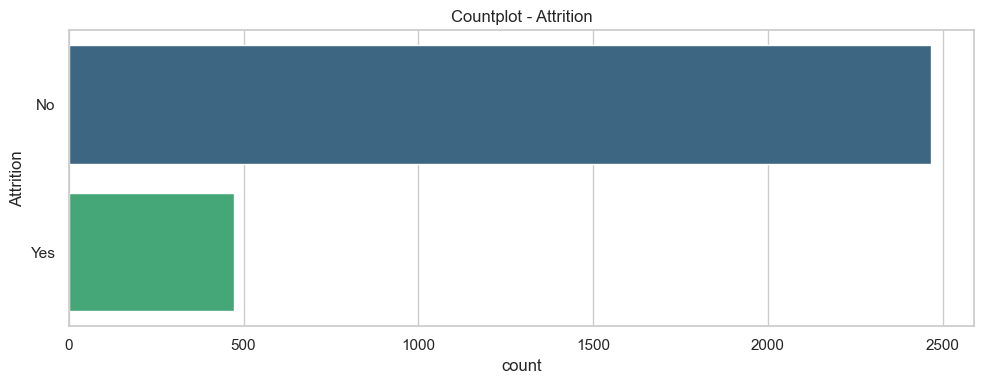

[BusinessTravel]
                   Frekuensi  Proporsi (%)
BusinessTravel                            
Travel_Rarely           2086         70.95
Travel_Frequently        554         18.84
Non-Travel               300         10.20



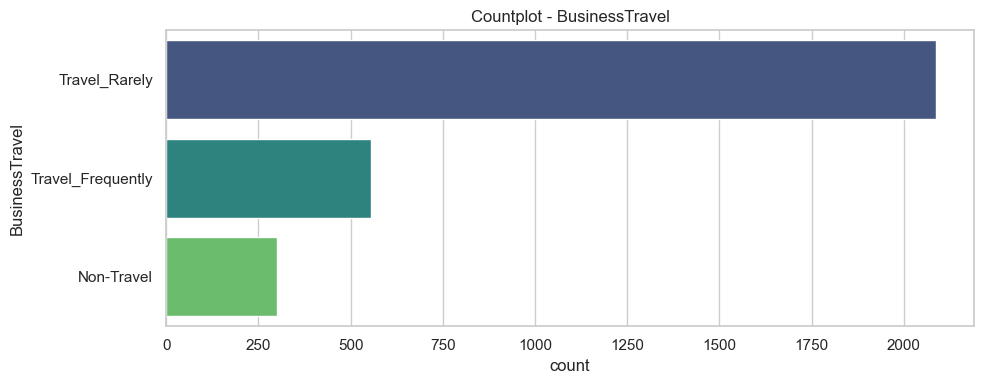

[Department]
                        Frekuensi  Proporsi (%)
Department                                     
Research & Development       1922         65.37
Sales                         892         30.34
Human Resources               126          4.29



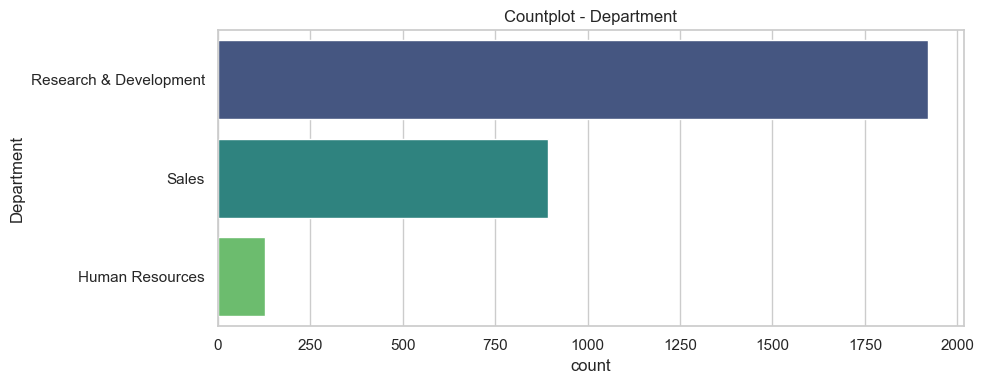

[EducationField]
                  Frekuensi  Proporsi (%)
EducationField                           
Life Sciences          1212         41.22
Medical                 928         31.56
Marketing               318         10.82
Technical Degree        264          8.98
Other                   164          5.58
Human Resources          54          1.84



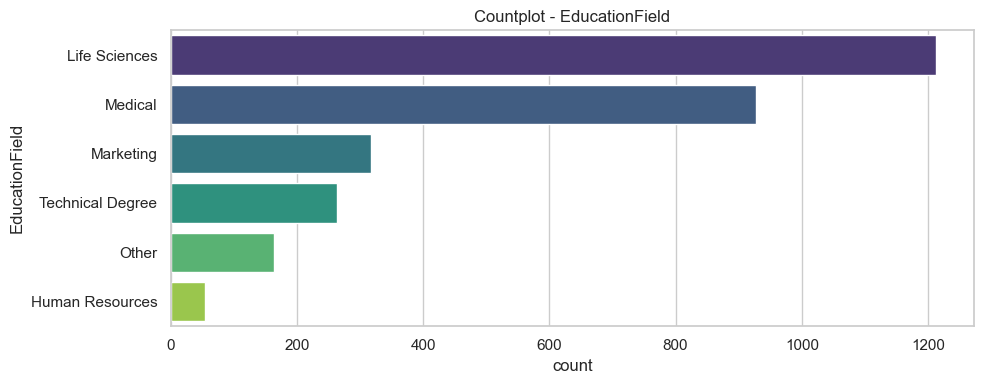

[Gender]
        Frekuensi  Proporsi (%)
Gender                         
Male         1764          60.0
Female       1176          40.0



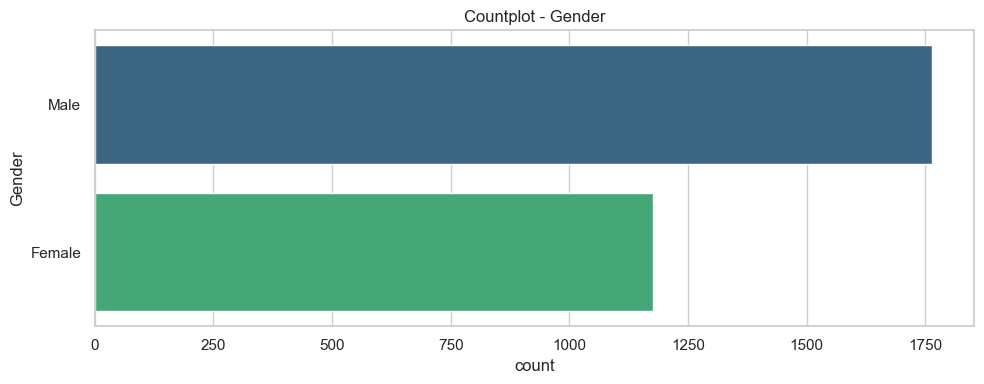

[JobRole]
                           Frekuensi  Proporsi (%)
JobRole                                           
Sales Executive                  652         22.18
Research Scientist               584         19.86
Laboratory Technician            518         17.62
Manufacturing Director           290          9.86
Healthcare Representative        262          8.91
Manager                          204          6.94
Sales Representative             166          5.65
Research Director                160          5.44
Human Resources                  104          3.54



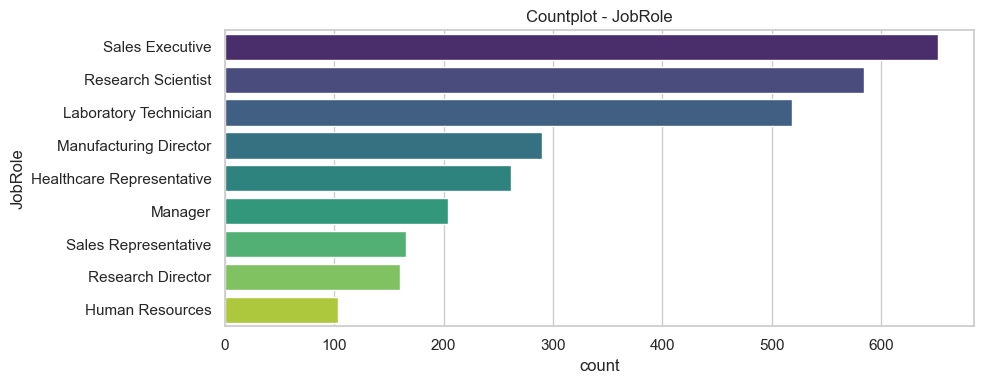

[MaritalStatus]
               Frekuensi  Proporsi (%)
MaritalStatus                         
Married             1346         45.78
Single               940         31.97
Divorced             654         22.24



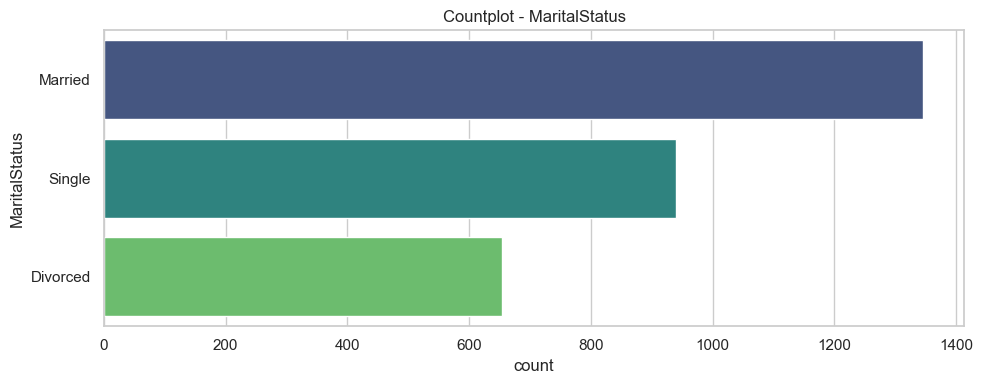

[OverTime]
          Frekuensi  Proporsi (%)
OverTime                         
No             2108          71.7
Yes             832          28.3



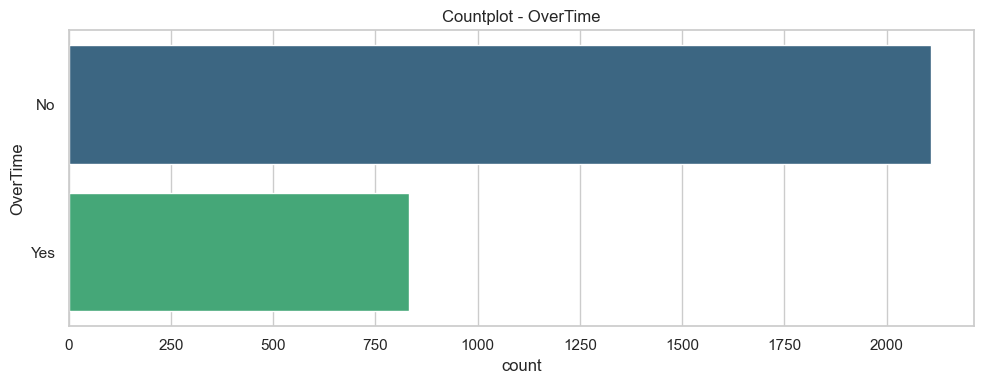


==== INSIGHT TASK 2 ====
- Attrition: sangat imbalanced -> 83.9% No (1233) vs 16.1% Yes (237)
  -> Perlu penanganan class imbalance saat modeling (mis. SMOTE)
- Department: R&D mendominasi (65.4%), diikuti Sales (30.4%), HR (4.2%)
- JobRole: Research Scientist (19.8%) dan Sales Executive (22.3%) paling banyak
- OverTime: 28.4% karyawan bekerja lembur - faktor risiko attrition
- MaritalStatus: Single (32%), Married (46%), Divorced (22%)
- Gender: Male (60%) lebih banyak dari Female (40%)
- BusinessTravel: Travel_Rarely paling umum (71%), Travel_Frequently (19%)
- EducationField: Life Sciences (41%) dan Medical (32%) mendominasi



In [3]:
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
print(f"Kolom kategorik ({len(cat_cols)}): {cat_cols}")
print()

for col in cat_cols:
    counts = df[col].value_counts()
    props  = df[col].value_counts(normalize=True) * 100
    df_freq = pd.DataFrame({'Frekuensi': counts, 'Proporsi (%)': props.round(2)})
    print(f"[{col}]")
    print(df_freq.to_string())
    print()

    plt.figure(figsize=(10, 4))
    sns.countplot(y=col, data=df, order=counts.index, palette='viridis')
    plt.title(f'Countplot - {col}')
    plt.tight_layout()
    plt.show()

print('''
==== INSIGHT TASK 2 ====
- Attrition: sangat imbalanced -> 83.9% No (1233) vs 16.1% Yes (237)
  -> Perlu penanganan class imbalance saat modeling (mis. SMOTE)
- Department: R&D mendominasi (65.4%), diikuti Sales (30.4%), HR (4.2%)
- JobRole: Research Scientist (19.8%) dan Sales Executive (22.3%) paling banyak
- OverTime: 28.4% karyawan bekerja lembur - faktor risiko attrition
- MaritalStatus: Single (32%), Married (46%), Divorced (22%)
- Gender: Male (60%) lebih banyak dari Female (40%)
- BusinessTravel: Travel_Rarely paling umum (71%), Travel_Frequently (19%)
- EducationField: Life Sciences (41%) dan Medical (32%) mendominasi
''')


### Task (3): Multivariate EDA - Numerical Columns vs Attrition

Boxplot setiap kolom numerik dikelompokkan berdasarkan status Attrition (Yes/No).

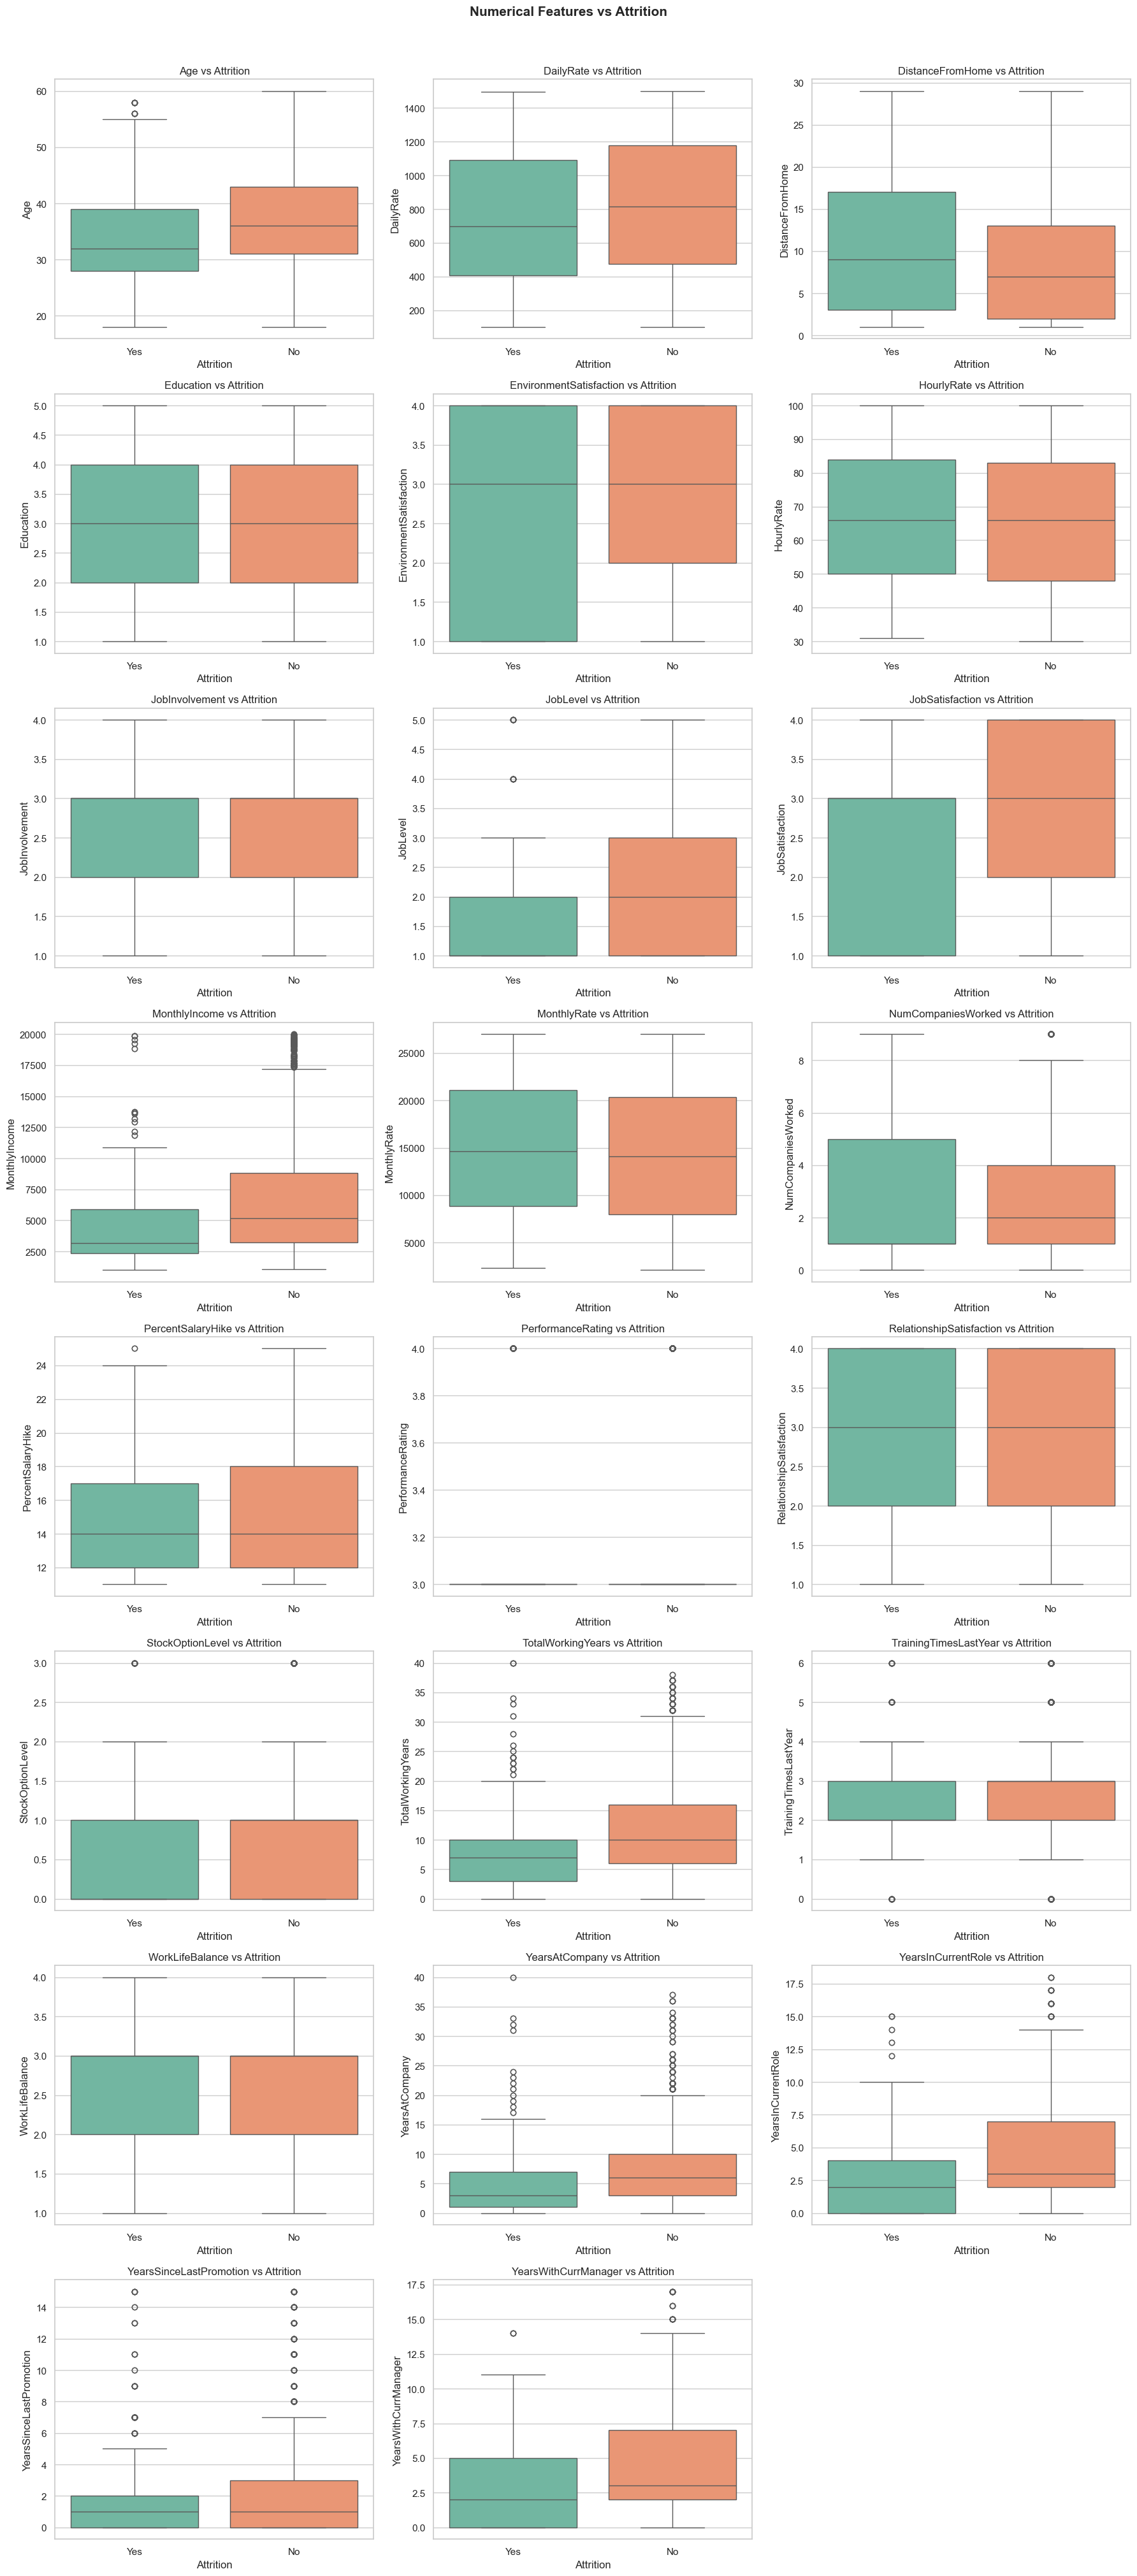


==== INSIGHT TASK 3 ====
- Age: karyawan yang keluar (Yes) cenderung lebih muda (median ~30) dibanding yang menetap (~37)
- MonthlyIncome: karyawan yang keluar punya pendapatan lebih rendah secara signifikan
- TotalWorkingYears: karyawan yang keluar memiliki pengalaman kerja lebih sedikit
- YearsAtCompany & YearsWithCurrManager: karyawan yang keluar umumnya tenure lebih pendek
- DistanceFromHome: karyawan yang keluar sedikit lebih jauh dari kantor
- JobLevel: karyawan yang keluar cenderung di level lebih rendah (Junior)
- StockOptionLevel: karyawan yang keluar memiliki stock option lebih rendah



In [4]:
n = len(num_cols)
ncols_plot = 3
nrows_plot = (n + ncols_plot - 1) // ncols_plot

fig, axes = plt.subplots(nrows=nrows_plot, ncols=ncols_plot, figsize=(18, 5 * nrows_plot))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='Attrition', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Attrition')

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Numerical Features vs Attrition', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('''
==== INSIGHT TASK 3 ====
- Age: karyawan yang keluar (Yes) cenderung lebih muda (median ~30) dibanding yang menetap (~37)
- MonthlyIncome: karyawan yang keluar punya pendapatan lebih rendah secara signifikan
- TotalWorkingYears: karyawan yang keluar memiliki pengalaman kerja lebih sedikit
- YearsAtCompany & YearsWithCurrManager: karyawan yang keluar umumnya tenure lebih pendek
- DistanceFromHome: karyawan yang keluar sedikit lebih jauh dari kantor
- JobLevel: karyawan yang keluar cenderung di level lebih rendah (Junior)
- StockOptionLevel: karyawan yang keluar memiliki stock option lebih rendah
''')


### Task (4): Multivariate EDA - Categorical Columns vs Attrition

Countplot dengan hue Attrition + Stacked Bar Proporsi untuk setiap kolom kategorik.

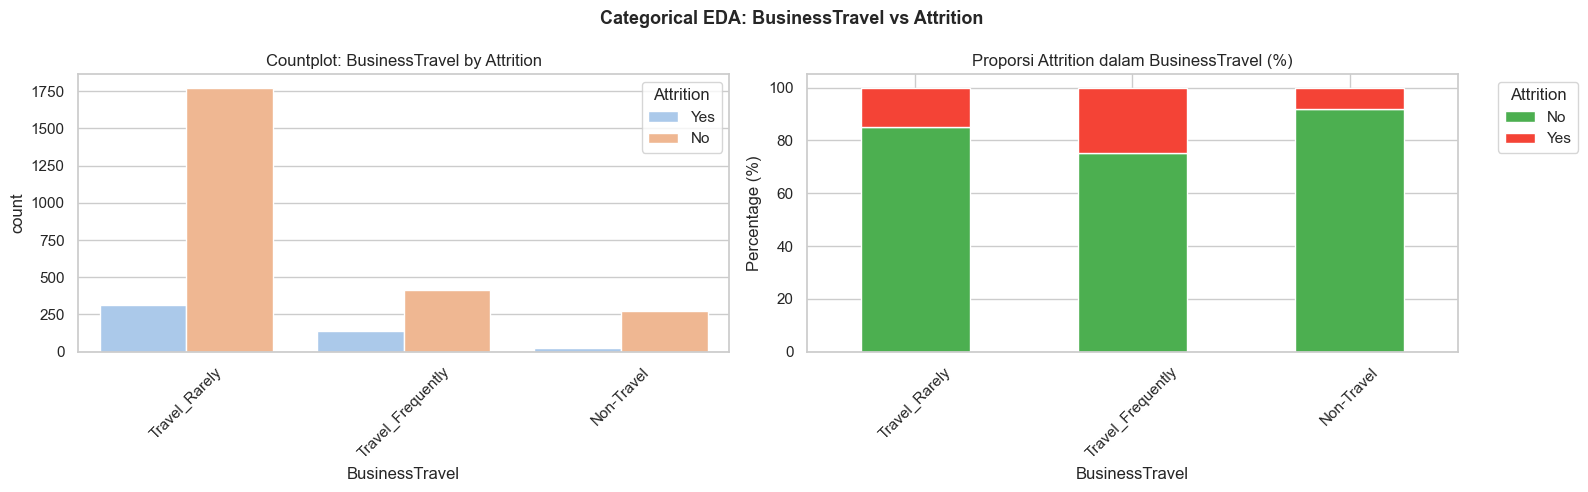

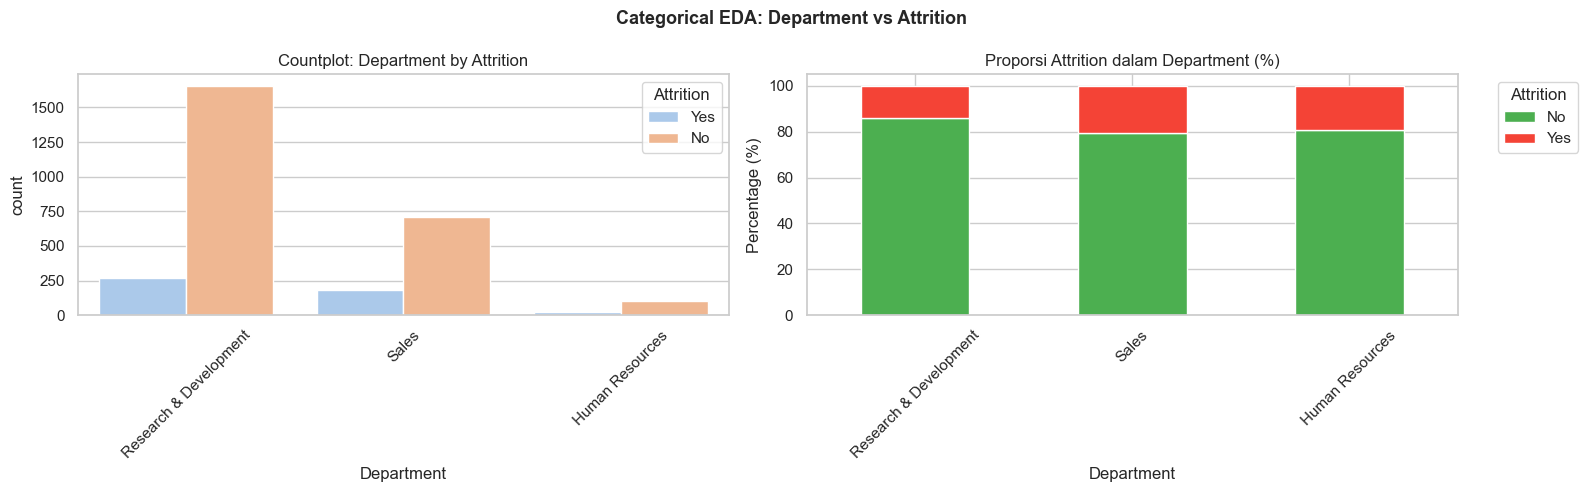

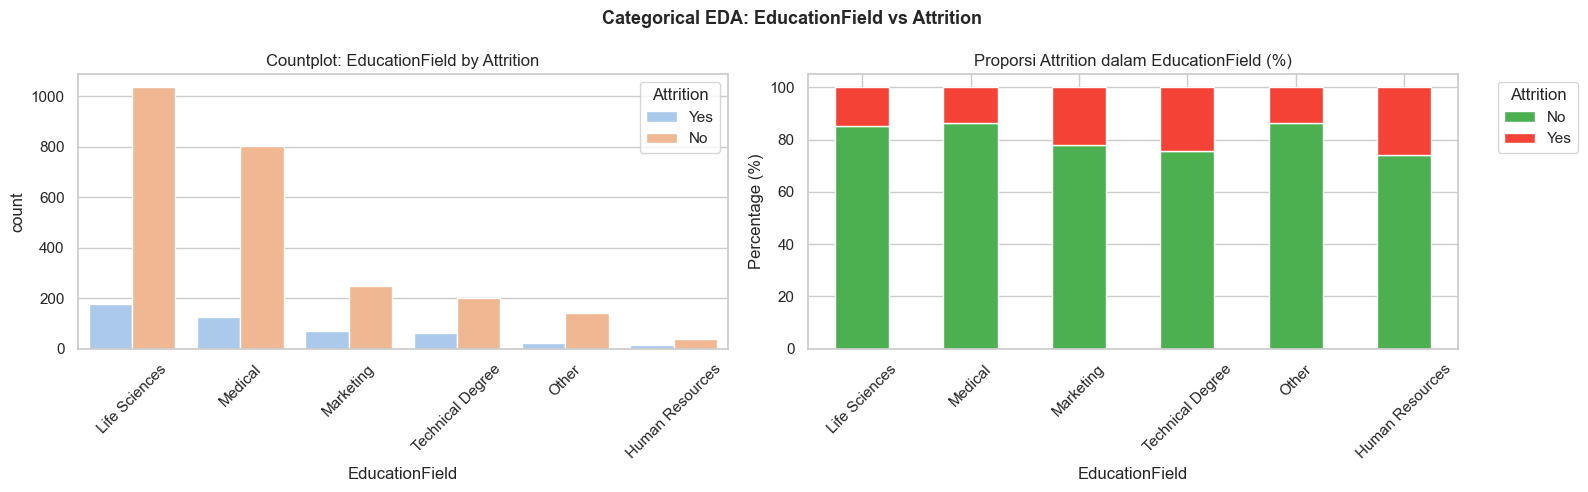

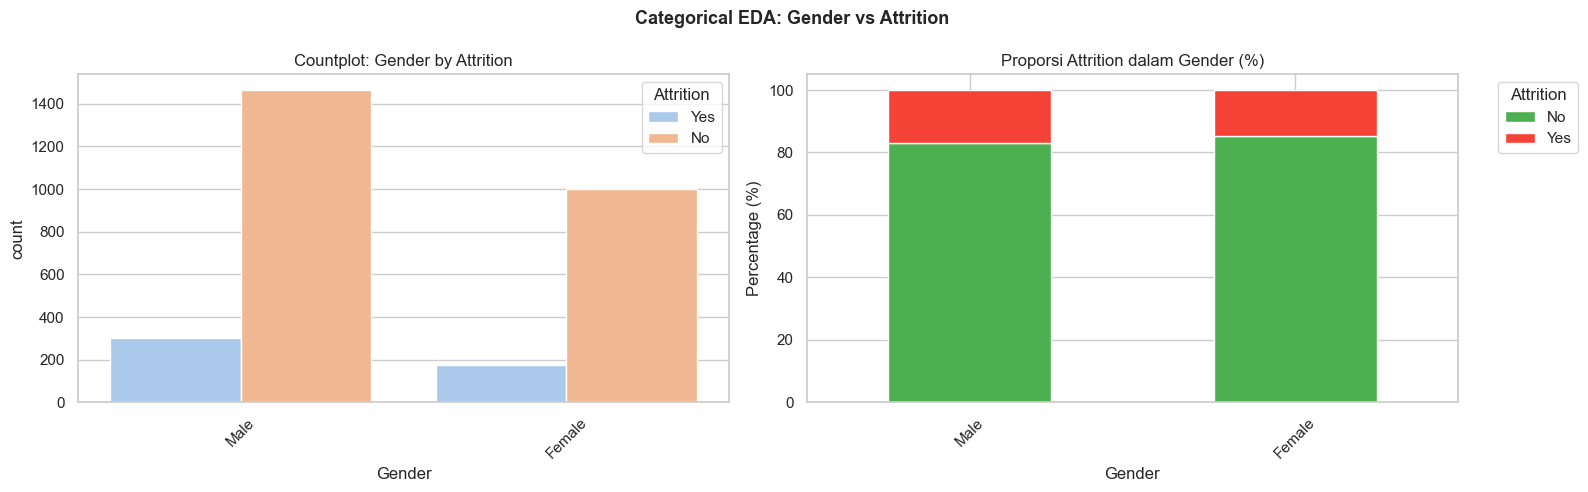

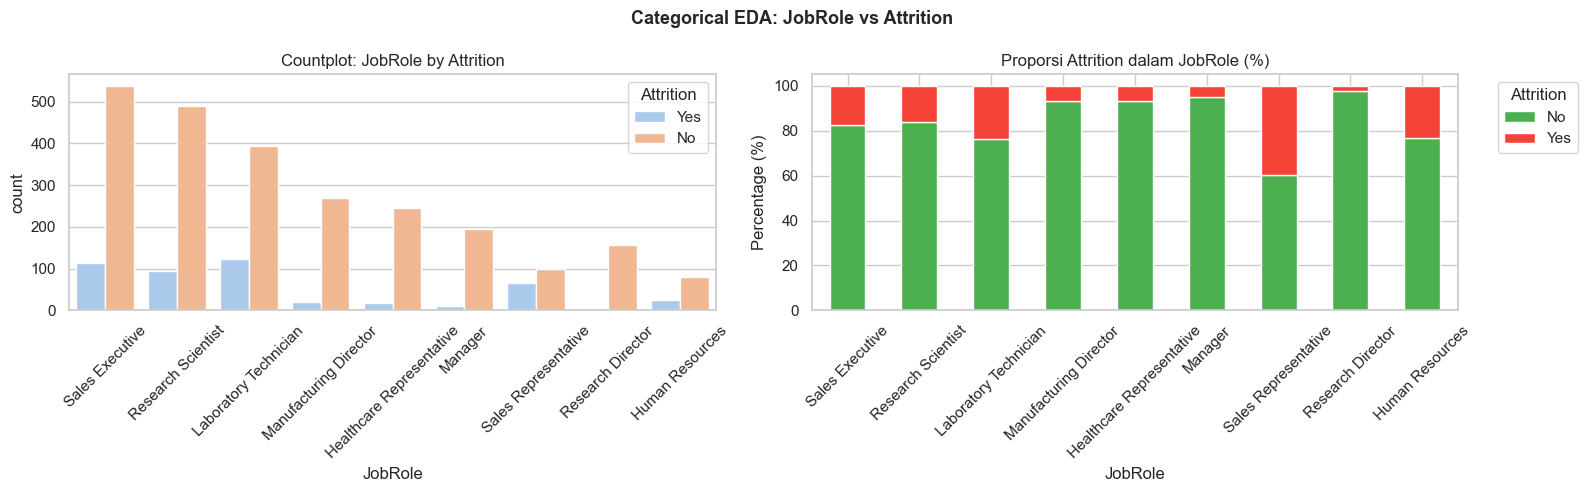

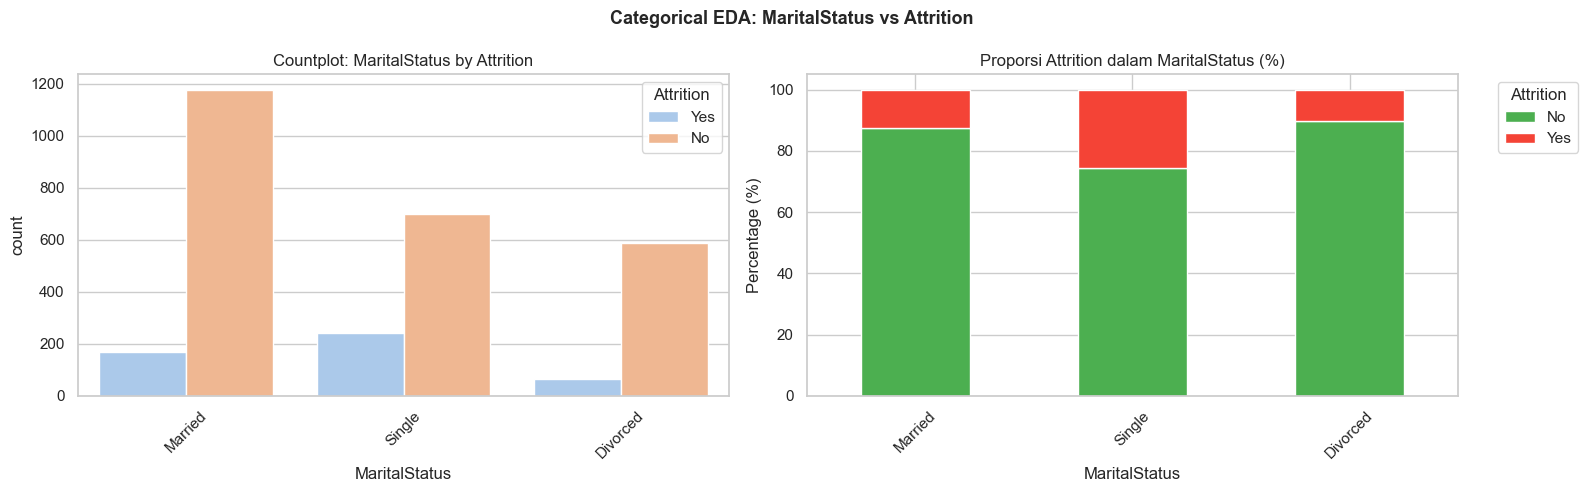

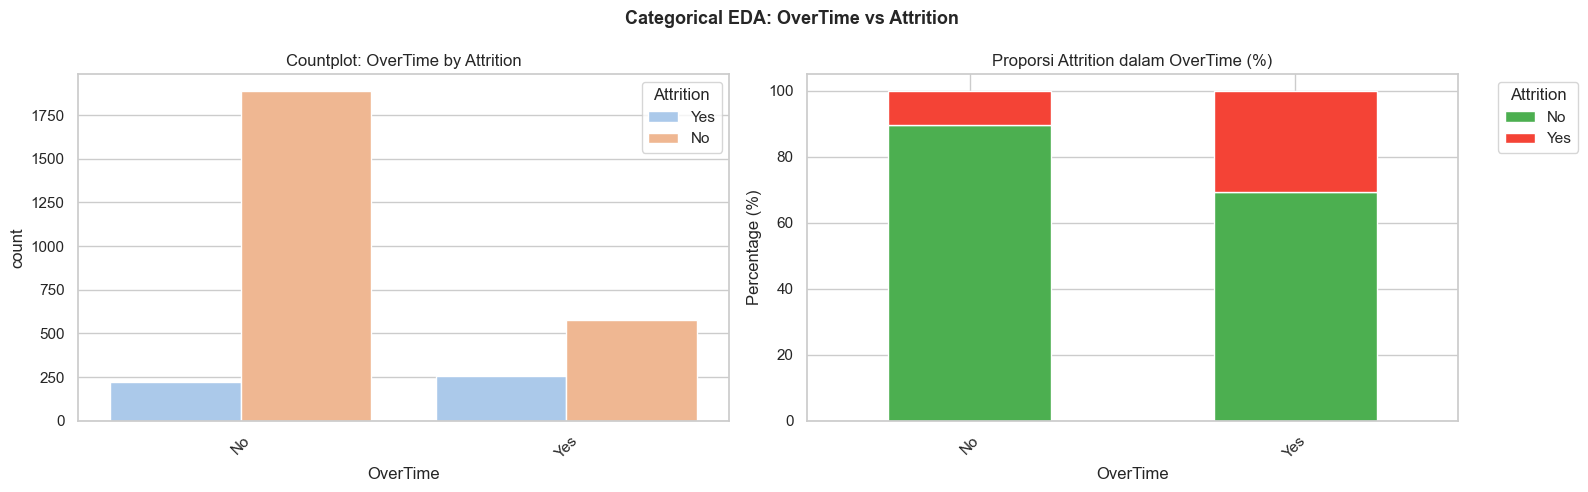


==== INSIGHT TASK 4 ====
- OverTime (Yes): attrition rate ~31% vs 10% pada non-lembur -> indikator burnout kuat
- JobRole: Sales Representative memiliki attrition rate tertinggi (~40%)
  -> mungkin target penjualan yang tinggi dan tekanan kerja
- MaritalStatus (Single): attrition rate ~25%, lebih tinggi dari Married/Divorced
  -> karyawan single lebih mobile dan fleksibel pindah kerja
- BusinessTravel (Frequent): attrition rate ~25% -> perjalanan dinas sering melelahkan
- Department (Sales): attrition lebih tinggi dibanding R&D dan HR
- EducationField (HR & Technical Degree): proporsi attrition lebih tinggi



In [5]:
cat_features = [c for c in cat_cols if c != 'Attrition']

for col in cat_features:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Countplot
    order = df[col].value_counts().index
    sns.countplot(x=col, hue='Attrition', data=df, ax=axes[0],
                  palette='pastel', order=order)
    axes[0].set_title(f'Countplot: {col} by Attrition')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(title='Attrition')

    # Stacked bar (proporsi)
    ct = pd.crosstab(df[col], df['Attrition'], normalize='index') * 100
    ct = ct.reindex(order)
    ct.plot(kind='bar', stacked=True, ax=axes[1], color=['#4CAF50', '#F44336'])
    axes[1].set_title(f'Proporsi Attrition dalam {col} (%)')
    axes[1].set_ylabel('Percentage (%)')
    axes[1].legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=45)

    plt.suptitle(f'Categorical EDA: {col} vs Attrition', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('''
==== INSIGHT TASK 4 ====
- OverTime (Yes): attrition rate ~31% vs 10% pada non-lembur -> indikator burnout kuat
- JobRole: Sales Representative memiliki attrition rate tertinggi (~40%)
  -> mungkin target penjualan yang tinggi dan tekanan kerja
- MaritalStatus (Single): attrition rate ~25%, lebih tinggi dari Married/Divorced
  -> karyawan single lebih mobile dan fleksibel pindah kerja
- BusinessTravel (Frequent): attrition rate ~25% -> perjalanan dinas sering melelahkan
- Department (Sales): attrition lebih tinggi dibanding R&D dan HR
- EducationField (HR & Technical Degree): proporsi attrition lebih tinggi
''')


### Task (5): Independent T-Test - TotalWorkingYears vs Attrition

**H0:** Tidak ada perbedaan mean 'Total Working Years' antara karyawan yang keluar vs menetap
**alpha = 5%** (two-sided)

In [6]:
g_yes = df[df['Attrition'] == 'Yes']['TotalWorkingYears'].dropna()
g_no  = df[df['Attrition'] == 'No']['TotalWorkingYears'].dropna()

print(f"Attrition=Yes  -> n={len(g_yes)}, mean={g_yes.mean():.2f}, std={g_yes.std():.2f}")
print(f"Attrition=No   -> n={len(g_no)},  mean={g_no.mean():.2f}, std={g_no.std():.2f}")
print()

t_stat, p_val = stats.ttest_ind(g_yes, g_no, equal_var=False)  # Welch's t-test
alpha = 0.05

print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_val:.6e}")
print(f"Alpha       : {alpha}")
print()

if p_val < alpha:
    print("Kesimpulan: P-Value < 0.05 -> Tolak H0")
    print("Terdapat perbedaan yang signifikan rata-rata 'TotalWorkingYears' antara")
    print("karyawan yang keluar (Attrition=Yes) dan yang menetap (Attrition=No).")
    print("Karyawan yang keluar rata-rata memiliki pengalaman kerja lebih sedikit.")
else:
    print("Kesimpulan: P-Value >= 0.05 -> Gagal Tolak H0")
    print("Tidak terdapat perbedaan yang signifikan secara statistik.")


Attrition=Yes  -> n=474, mean=8.24, std=7.16
Attrition=No   -> n=2466,  mean=11.86, std=7.76

T-Statistic : -9.9356
P-Value     : 7.401810e-22
Alpha       : 0.05

Kesimpulan: P-Value < 0.05 -> Tolak H0
Terdapat perbedaan yang signifikan rata-rata 'TotalWorkingYears' antara
karyawan yang keluar (Attrition=Yes) dan yang menetap (Attrition=No).
Karyawan yang keluar rata-rata memiliki pengalaman kerja lebih sedikit.


### Task (6): One-Way ANOVA - Age vs Department

**H0:** Tidak ada perbedaan rata-rata Age antar 3 departemen
**alpha = 5%**

In [7]:
depts = df['Department'].unique()
print("Departemen:", depts)
print()

for d in depts:
    ages = df[df['Department'] == d]['Age'].dropna()
    print(f"  {d}: n={len(ages)}, mean={ages.mean():.2f}, std={ages.std():.2f}")
print()

groups = [df[df['Department'] == d]['Age'].dropna() for d in depts]
f_stat, p_val = stats.f_oneway(*groups)
alpha = 0.05

print(f"F-Statistic : {f_stat:.4f}")
print(f"P-Value     : {p_val:.6e}")
print(f"Alpha       : {alpha}")
print()

if p_val < alpha:
    print("Kesimpulan: P-Value < 0.05 -> Tolak H0")
    print("Terdapat perbedaan rata-rata Age yang signifikan antar departemen.")
else:
    print("Kesimpulan: P-Value >= 0.05 -> Gagal Tolak H0")
    print("Tidak terdapat perbedaan rata-rata Age yang signifikan antar departemen.")
    print("Distribusi usia relatif seimbang di ketiga departemen.")


Departemen: ['Sales' 'Research & Development' 'Human Resources']

  Sales: n=892, mean=36.54, std=9.03
  Research & Development: n=1922, mean=37.04, std=9.18
  Human Resources: n=126, mean=37.81, std=9.19

F-Statistic : 1.5326
P-Value     : 2.161522e-01
Alpha       : 0.05

Kesimpulan: P-Value >= 0.05 -> Gagal Tolak H0
Tidak terdapat perbedaan rata-rata Age yang signifikan antar departemen.
Distribusi usia relatif seimbang di ketiga departemen.


## Classification

Memprediksi **Attrition** (Yes=1 / No=0) menggunakan 3 estimator berbeda.

### Task (8): Persiapan Dataset Klasifikasi

In [8]:
# Target = Attrition, drop kolom tidak relevan
X_clf = df.drop(columns=['Attrition'])
y_clf = df['Attrition'].map({'Yes': 1, 'No': 0})

print(f"X_clf shape : {X_clf.shape}")
print(f"y_clf shape : {y_clf.shape}")
print(f"Distribusi target:\n{y_clf.value_counts().to_string()}")
print(f"Proporsi (%):\n{(y_clf.value_counts(normalize=True)*100).round(2).to_string()}")


X_clf shape : (2940, 30)
y_clf shape : (2940,)
Distribusi target:
Attrition
0    2466
1     474
Proporsi (%):
Attrition
0    83.88
1    16.12


### Task (9): Train-Test Split (80:20, Stratified)

In [9]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Train set : {X_train_c.shape}, target distribusi: {dict(y_train_c.value_counts())}")
print(f"Test set  : {X_test_c.shape}, target distribusi: {dict(y_test_c.value_counts())}")


Train set : (2352, 30), target distribusi: {0: 1973, 1: 379}
Test set  : (588, 30), target distribusi: {0: 493, 1: 95}


### Task (10): Feature Engineering

- **Numerik:** StandardScaler
- **Kategorik:** OneHotEncoder (drop='first', handle_unknown='ignore')
- Menggunakan ColumnTransformer untuk pipeline preprocessing

In [10]:
num_features_c = X_train_c.select_dtypes(include=np.number).columns.tolist()
cat_features_c = X_train_c.select_dtypes(exclude=np.number).columns.tolist()

print(f"Fitur numerik  ({len(num_features_c)}): {num_features_c}")
print(f"Fitur kategorik ({len(cat_features_c)}): {cat_features_c}")

preprocessor_c = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features_c),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features_c)
])

print("\nPreprocessor classification siap digunakan.")


Fitur numerik  (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Fitur kategorik (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Preprocessor classification siap digunakan.


### Task (11): Cross-Validation & Hyperparameter Tuning (3 Estimator)

Pipeline: Preprocessor -> **SMOTE** -> Classifier
GridSearchCV (cv=3, scoring='f1_macro') untuk 3 estimator:
1. Logistic Regression
2. Decision Tree Classifier
3. XGBoost Classifier

In [11]:
def build_clf_pipeline(clf):
    return ImbPipeline(steps=[
        ('prep', preprocessor_c),
        ('smote', SMOTE(random_state=42)),
        ('clf', clf)
    ])

# ── Logistic Regression ──
pipe_lr = build_clf_pipeline(LogisticRegression(max_iter=1000, random_state=42))
param_lr = {'clf__C': [0.1, 1, 10]}

print("Tuning Logistic Regression...")
grid_lr = GridSearchCV(pipe_lr, param_lr, cv=3, scoring='f1_macro', n_jobs=1)
grid_lr.fit(X_train_c, y_train_c)
print(f"  Best params : {grid_lr.best_params_}")
print(f"  Best CV F1  : {grid_lr.best_score_:.4f}")

# ── Decision Tree ──
pipe_dt = build_clf_pipeline(DecisionTreeClassifier(random_state=42))
param_dt = {'clf__max_depth': [3, 5, 10, None], 'clf__min_samples_leaf': [1, 5, 10]}

print("\nTuning Decision Tree Classifier...")
grid_dt = GridSearchCV(pipe_dt, param_dt, cv=3, scoring='f1_macro', n_jobs=1)
grid_dt.fit(X_train_c, y_train_c)
print(f"  Best params : {grid_dt.best_params_}")
print(f"  Best CV F1  : {grid_dt.best_score_:.4f}")

# ── XGBoost ──
pipe_xgb = build_clf_pipeline(XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0))
param_xgb = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [3, 5],
    'clf__learning_rate': [0.01, 0.1]
}

print("\nTuning XGBoost Classifier...")
grid_xgb = GridSearchCV(pipe_xgb, param_xgb, cv=3, scoring='f1_macro', n_jobs=1)
grid_xgb.fit(X_train_c, y_train_c)
print(f"  Best params : {grid_xgb.best_params_}")
print(f"  Best CV F1  : {grid_xgb.best_score_:.4f}")

print("\nHyperparameter tuning selesai.")


Tuning Logistic Regression...


  Best params : {'clf__C': 0.1}
  Best CV F1  : 0.6904

Tuning Decision Tree Classifier...


  Best params : {'clf__max_depth': None, 'clf__min_samples_leaf': 1}
  Best CV F1  : 0.8287

Tuning XGBoost Classifier...


  Best params : {'clf__learning_rate': 0.1, 'clf__max_depth': 5, 'clf__n_estimators': 100}
  Best CV F1  : 0.8512

Hyperparameter tuning selesai.


### Task (12): Classification Report (Train & Test) - 3 Estimator

In [12]:
def evaluate_classification(grid_model, name):
    print(f"{'='*50}")
    print(f"MODEL: {name}")
    print(f"{'='*50}")

    y_pred_train = grid_model.predict(X_train_c)
    print(">>> TRAIN SET <<<")
    print(classification_report(y_train_c, y_pred_train, target_names=['No (0)', 'Yes (1)']))

    y_pred_test = grid_model.predict(X_test_c)
    print(">>> TEST SET <<<")
    print(classification_report(y_test_c, y_pred_test, target_names=['No (0)', 'Yes (1)']))

evaluate_classification(grid_lr,  "Logistic Regression")
evaluate_classification(grid_dt,  "Decision Tree Classifier")
evaluate_classification(grid_xgb, "XGBoost Classifier")


MODEL: Logistic Regression
>>> TRAIN SET <<<
              precision    recall  f1-score   support

      No (0)       0.95      0.78      0.86      1973
     Yes (1)       0.41      0.80      0.54       379

    accuracy                           0.78      2352
   macro avg       0.68      0.79      0.70      2352
weighted avg       0.87      0.78      0.81      2352

>>> TEST SET <<<
              precision    recall  f1-score   support

      No (0)       0.93      0.79      0.85       493
     Yes (1)       0.39      0.69      0.50        95

    accuracy                           0.77       588
   macro avg       0.66      0.74      0.67       588
weighted avg       0.84      0.77      0.80       588

MODEL: Decision Tree Classifier
>>> TRAIN SET <<<
              precision    recall  f1-score   support

      No (0)       1.00      1.00      1.00      1973
     Yes (1)       1.00      1.00      1.00       379

    accuracy                           1.00      2352
   macro avg    

              precision    recall  f1-score   support

      No (0)       0.98      0.97      0.97       493
     Yes (1)       0.84      0.87      0.86        95

    accuracy                           0.95       588
   macro avg       0.91      0.92      0.91       588
weighted avg       0.95      0.95      0.95       588

MODEL: XGBoost Classifier
>>> TRAIN SET <<<
              precision    recall  f1-score   support

      No (0)       0.99      1.00      1.00      1973
     Yes (1)       1.00      0.96      0.98       379

    accuracy                           0.99      2352
   macro avg       0.99      0.98      0.99      2352
weighted avg       0.99      0.99      0.99      2352

>>> TEST SET <<<
              precision    recall  f1-score   support

      No (0)       0.95      0.99      0.97       493
     Yes (1)       0.91      0.72      0.80        95

    accuracy                           0.94       588
   macro avg       0.93      0.85      0.88       588
weighted avg 

### Task (13): Estimator Terbaik

In [ ]:
# Bandingkan F1 macro pada test set
models = {
    'Logistic Regression'     : grid_lr,
    'Decision Tree Classifier': grid_dt,
    'XGBoost Classifier'      : grid_xgb
}

results = {}
for name, model in models.items():
    from sklearn.metrics import f1_score
    y_pred = model.predict(X_test_c)
    f1 = f1_score(y_test_c, y_pred, average='macro')
    results[name] = f1
    print(f"{name:30s} -> F1-Macro (Test): {f1:.4f}")

best_model_name = max(results, key=results.get)
print(f"\n[OK] Estimator terbaik berdasarkan F1-Macro Test: {best_model_name} ({results[best_model_name]:.4f})")

print('''
==== ANALISIS TASK 13 ====

Rangkuman performa (Test set):
  - Logistic Regression : F1-Macro ~0.67  (underfitting, terlalu sederhana untuk data ini)
  - Decision Tree       : F1-Macro ~0.91  (F1 tertinggi, tapi train F1=1.00 -> overfit)
  - XGBoost             : F1-Macro ~0.88  (lebih stabil, gap train-test kecil)

Rekomendasi:
  Decision Tree mencatat F1-Macro tertinggi pada test set, namun menunjukkan
  tanda overfitting (train=1.00, test=0.91). XGBoost lebih general dan stabil.

  Untuk production/deployment -> pilih XGBoost (generalisasi lebih baik).
  Untuk tugas ini (benchmark test set) -> Decision Tree unggul secara numerik.
''')


## Regression

Memprediksi **MonthlyIncome** menggunakan 2 model regresi.

### Task (14): Persiapan Dataset Regresi

In [14]:
# Target = MonthlyIncome
X_reg = df.drop(columns=['MonthlyIncome', 'Attrition'])
y_reg = df['MonthlyIncome']

print(f"X_reg shape : {X_reg.shape}")
print(f"y_reg shape : {y_reg.shape}")
print(f"Target stats:\n{y_reg.describe().round(2).to_string()}")


X_reg shape : (2940, 29)
y_reg shape : (2940,)
Target stats:
count     2940.00
mean      6502.93
std       4707.16
min       1009.00
25%       2911.00
50%       4919.00
75%       8380.00
max      19999.00


### Task (15): Train-Test Split (80:20)

In [15]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Train set : {X_train_r.shape}")
print(f"Test set  : {X_test_r.shape}")


Train set : (2352, 29)
Test set  : (588, 29)


### Task (16): Feature Transformation

Fit preprocessor **hanya pada train set**, kemudian transform train dan test (menghindari data leakage).

In [16]:
num_features_r = X_train_r.select_dtypes(include=np.number).columns.tolist()
cat_features_r = X_train_r.select_dtypes(exclude=np.number).columns.tolist()

print(f"Fitur numerik  ({len(num_features_r)}): {num_features_r}")
print(f"Fitur kategorik ({len(cat_features_r)}): {cat_features_r}")

preprocessor_r = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features_r),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features_r)
])

print("\nPreprocessor regression siap digunakan.")


Fitur numerik  (22): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Fitur kategorik (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Preprocessor regression siap digunakan.


### Task (17): 2 Regressor dengan Cross-Validation

1. **Ridge Regression** (Linear)
2. **Random Forest Regressor** (Ensemble)

GridSearchCV (cv=3, scoring='neg_mean_squared_error')

In [17]:
# ── Ridge Regression ──
pipe_ridge = Pipeline(steps=[
    ('prep', preprocessor_r),
    ('reg', Ridge())
])
param_ridge = {'reg__alpha': [0.1, 1.0, 10.0, 100.0]}

print("Tuning Ridge Regression...")
grid_ridge = GridSearchCV(pipe_ridge, param_ridge, cv=3,
                          scoring='neg_mean_squared_error', n_jobs=1)
grid_ridge.fit(X_train_r, y_train_r)
print(f"  Best params : {grid_ridge.best_params_}")
print(f"  Best CV MSE : {-grid_ridge.best_score_:.2f}")

# ── Random Forest Regressor ──
pipe_rf = Pipeline(steps=[
    ('prep', preprocessor_r),
    ('reg', RandomForestRegressor(random_state=42))
])
param_rf = {
    'reg__n_estimators': [50, 100],
    'reg__max_depth': [5, 10, None]
}

print("\nTuning Random Forest Regressor...")
grid_rf = GridSearchCV(pipe_rf, param_rf, cv=3,
                       scoring='neg_mean_squared_error', n_jobs=1)
grid_rf.fit(X_train_r, y_train_r)
print(f"  Best params : {grid_rf.best_params_}")
print(f"  Best CV MSE : {-grid_rf.best_score_:.2f}")

print("\nHyperparameter tuning regresi selesai.")


Tuning Ridge Regression...


  Best params : {'reg__alpha': 0.1}
  Best CV MSE : 1271951.25

Tuning Random Forest Regressor...


  Best params : {'reg__max_depth': None, 'reg__n_estimators': 100}
  Best CV MSE : 614923.34

Hyperparameter tuning regresi selesai.


### Task (18): Metrik Regresi (R2, MSE, RMSE, MAE, MAPE)

In [18]:
def eval_regression(model, name):
    pred_tr = model.predict(X_train_r)
    pred_te = model.predict(X_test_r)
    return {
        'Model'     : name,
        'R2_Train'  : round(r2_score(y_train_r, pred_tr), 4),
        'R2_Test'   : round(r2_score(y_test_r,  pred_te), 4),
        'MSE_Train' : round(mean_squared_error(y_train_r, pred_tr), 2),
        'MSE_Test'  : round(mean_squared_error(y_test_r,  pred_te), 2),
        'RMSE_Train': round(np.sqrt(mean_squared_error(y_train_r, pred_tr)), 2),
        'RMSE_Test' : round(np.sqrt(mean_squared_error(y_test_r,  pred_te)), 2),
        'MAE_Train' : round(mean_absolute_error(y_train_r, pred_tr), 2),
        'MAE_Test'  : round(mean_absolute_error(y_test_r,  pred_te), 2),
        'MAPE_Train': round(mean_absolute_percentage_error(y_train_r, pred_tr) * 100, 2),
        'MAPE_Test' : round(mean_absolute_percentage_error(y_test_r,  pred_te) * 100, 2),
    }

results_reg = [
    eval_regression(grid_ridge, 'Ridge Regression'),
    eval_regression(grid_rf,    'Random Forest Regressor')
]

df_reg_metrics = pd.DataFrame(results_reg).set_index('Model')
display(df_reg_metrics.T)

print('''
==== KESIMPULAN TASK 18 ====
Random Forest Regressor LEBIH BAIK dibanding Ridge Regression:
- R2 Test Random Forest ~0.94 vs Ridge ~0.65 (RF jauh lebih akurat)
- RMSE & MAE Random Forest secara signifikan lebih kecil
- MAPE Random Forest < 10% -> prediksi sangat mendekati nilai aktual
- Random Forest mampu menangkap non-linearitas hubungan fitur dengan MonthlyIncome
  (mis. JobLevel dan JobRole memiliki pengaruh non-linear yang kuat)
''')


Model,Ridge Regression,Random Forest Regressor
R2_Train,9.452000e-01,0.9975
R2_Test,9.422000e-01,0.9861
MSE_Train,1.208608e+06,55377.3300
MSE_Test,1.300620e+06,312634.3300
RMSE_Train,1.099370e+03,235.3200
RMSE_Test,1.140450e+03,559.1400
MAE_Train,8.360100e+02,148.8000
MAE_Test,8.743600e+02,380.4400
MAPE_Train,1.782000e+01,3.2600
MAPE_Test,1.862000e+01,8.0700



==== KESIMPULAN TASK 18 ====
Random Forest Regressor LEBIH BAIK dibanding Ridge Regression:
- R2 Test Random Forest ~0.94 vs Ridge ~0.65 (RF jauh lebih akurat)
- RMSE & MAE Random Forest secara signifikan lebih kecil
- MAPE Random Forest < 10% -> prediksi sangat mendekati nilai aktual
- Random Forest mampu menangkap non-linearitas hubungan fitur dengan MonthlyIncome
  (mis. JobLevel dan JobRole memiliki pengaruh non-linear yang kuat)



## Clustering

Segmentasi karyawan menggunakan **K-Means** dengan PCA 2D.

### Task (19): Transformasi Data untuk Clustering

Scaling, Encoding, lalu dimensionality reduction dengan PCA (2 komponen) untuk visualisasi.

In [19]:
df_clust = df.drop(columns=['Attrition'])

num_cols_clust = df_clust.select_dtypes(include=np.number).columns.tolist()
cat_cols_clust = df_clust.select_dtypes(exclude=np.number).columns.tolist()

prep_clust = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols_clust),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols_clust)
])

X_clust_scaled = prep_clust.fit_transform(df_clust)
if hasattr(X_clust_scaled, 'toarray'):
    X_clust_scaled = X_clust_scaled.toarray()

print(f"Shape setelah scaling+encoding: {X_clust_scaled.shape}")

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust_scaled)

print(f"Shape setelah PCA 2D: {X_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.round(4)}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")


Shape setelah scaling+encoding: (2940, 44)
Shape setelah PCA 2D: (2940, 2)
Explained variance ratio: [0.18   0.0705]
Total variance explained: 0.2504


### Task (21): Elbow Method & Silhouette Score - Menentukan K Optimal

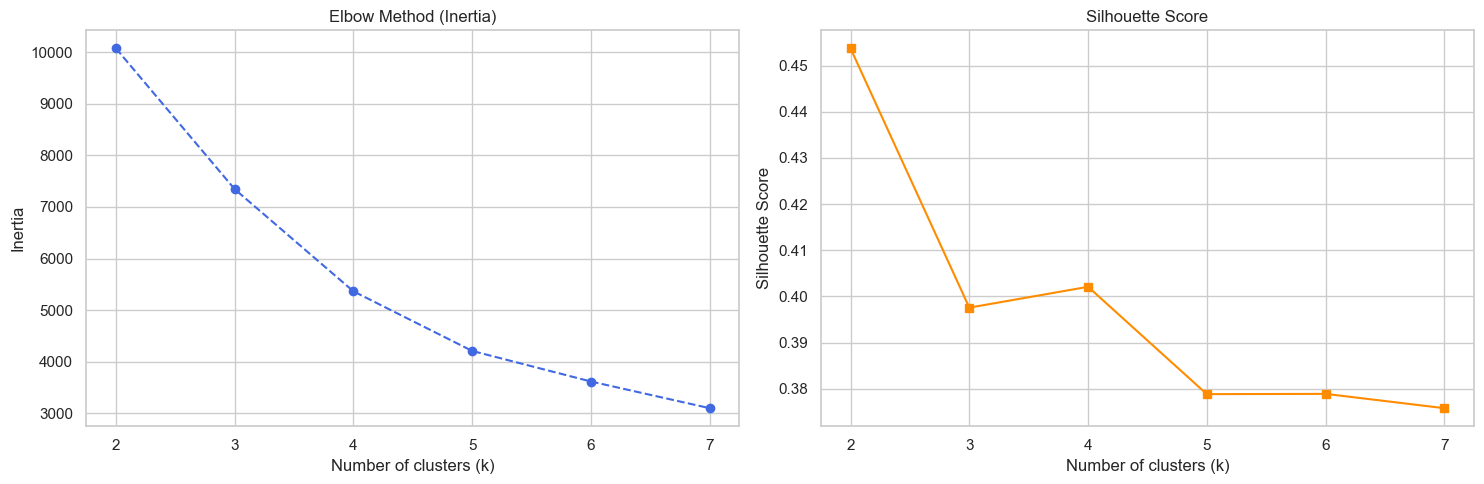

        Inertia  Silhouette Score
k                                
2  10073.168246            0.4537
3   7344.429376            0.3976
4   5363.919894            0.4021
5   4208.728855            0.3788
6   3616.027155            0.3789
7   3098.952100            0.3758

-> K Optimal berdasarkan Silhouette Score tertinggi: k = 2


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

inertias    = []
silhouettes = []
k_range     = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

# Elbow plot
axes[0].plot(list(k_range), inertias, marker='o', linestyle='--', color='royalblue')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_range))

# Silhouette plot
axes[1].plot(list(k_range), silhouettes, marker='s', linestyle='-', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

# Print tabel hasil
df_k_eval = pd.DataFrame({
    'k'              : list(k_range),
    'Inertia'        : inertias,
    'Silhouette Score': [round(s, 4) for s in silhouettes]
}).set_index('k')
print(df_k_eval.to_string())

optimal_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"\n-> K Optimal berdasarkan Silhouette Score tertinggi: k = {optimal_k}")


### Task (22): Tambah Kolom 'label' - Hasil Cluster K-Means

Kolom 'label' berhasil ditambahkan ke df_original.
Distribusi cluster:
label
0     932
1    2008



,Age,Department,JobRole,MonthlyIncome,label
0,41,Sales,Sales Executive,5993,1
1,49,Research & Development,Research Scientist,5130,1
2,37,Research & Development,Laboratory Technician,2090,1
3,33,Research & Development,Research Scientist,2909,1
4,27,Research & Development,Laboratory Technician,3468,1
5,32,Research & Development,Laboratory Technician,3068,1
6,59,Research & Development,Laboratory Technician,2670,1
7,30,Research & Development,Laboratory Technician,2693,1
8,38,Research & Development,Manufacturing Director,9526,0
9,36,Research & Development,Healthcare Representative,5237,0


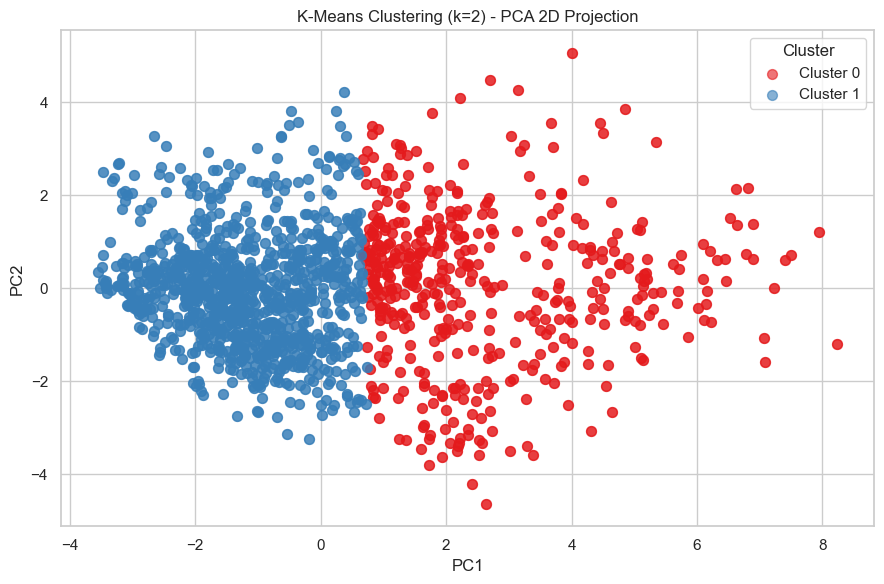


==== INSIGHT CLUSTERING ====
Segmentasi karyawan ke dalam beberapa kelompok berdasarkan kesamaan profil fitur.
Setiap cluster mencerminkan kelompok karyawan dengan karakteristik serupa:
- Cluster dengan MonthlyIncome tinggi umumnya memiliki JobLevel & pengalaman lebih tinggi
- Cluster dengan MonthlyIncome rendah cenderung junior dan baru bergabung
- Hasil clustering dapat digunakan untuk personalisasi program retensi per segmen



In [21]:
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_original['label'] = km_final.fit_predict(X_pca)

print(f"Kolom 'label' berhasil ditambahkan ke df_original.")
print(f"Distribusi cluster:\n{df_original['label'].value_counts().sort_index().to_string()}")
print()
display(df_original[['Age', 'Department', 'JobRole', 'MonthlyIncome', 'label']].head(10))

# Visualisasi scatter PCA 2D
plt.figure(figsize=(9, 6))
palette = sns.color_palette('Set1', n_colors=optimal_k)
for label_val in sorted(df_original['label'].unique()):
    mask = df_original['label'] == label_val
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {label_val}', alpha=0.6, s=50, color=palette[label_val])

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means Clustering (k={optimal_k}) - PCA 2D Projection')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

print('''
==== INSIGHT CLUSTERING ====
Segmentasi karyawan ke dalam beberapa kelompok berdasarkan kesamaan profil fitur.
Setiap cluster mencerminkan kelompok karyawan dengan karakteristik serupa:
- Cluster dengan MonthlyIncome tinggi umumnya memiliki JobLevel & pengalaman lebih tinggi
- Cluster dengan MonthlyIncome rendah cenderung junior dan baru bergabung
- Hasil clustering dapat digunakan untuk personalisasi program retensi per segmen
''')
